Carregar todas bibliotecas necessárias para execução do código:

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from joblib import dump
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, ConfusionMatrixDisplay
import pandas as pd
import shap
import matplotlib.pyplot as plt

Primeiro passo é extrair o CICIoT 2023, logo depois é processar o arquivo em chunks para criação do dataset com ataques de mirai e tráfego benigno que é nossa área de pesquisa:

In [5]:
# Caminho para o arquivo grande
file_path = "/home/michael/Mestrado/METODOS_QT/DatasetFull/CIC_IoT_Dataset_Unificado.csv"

# Caminho para o arquivo de saída
output_path = "/home/michael/Mestrado/METODOS_QT/DatasetFull/CIC_IoT_Dataset_Unificado_resumido.csv"

# Tamanho do chunk
chunk_size = 100000

# Inicializar um arquivo de saída vazio
with open(output_path, 'w') as output_file:
    # Processar o arquivo em chunks
    for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
        print(f"Processando chunk {i + 1}")
        
        # Filtrar dados que interessam (exemplo: manter apenas "Mirai" e "BenignTraffic")
        filtered_chunk = chunk[
            chunk['label'].str.contains('Mirai', regex=True) | 
            (chunk['label'] == 'BenignTraffic')
        ]
        
        if i == 0:
            # Escrever cabeçalho no primeiro chunk
            filtered_chunk.to_csv(output_file, index=False, mode='w')
        else:
            # Para chunks subsequentes, não incluir cabeçalho
            filtered_chunk.to_csv(output_file, index=False, mode='a', header=False)

print(f"Processo concluído. Dados filtrados salvos em {output_path}")


Processando chunk 1
Processando chunk 2
Processando chunk 3
Processando chunk 4
Processando chunk 5
Processando chunk 6
Processando chunk 7
Processando chunk 8
Processando chunk 9
Processando chunk 10
Processando chunk 11
Processando chunk 12
Processando chunk 13
Processando chunk 14
Processando chunk 15
Processando chunk 16
Processando chunk 17
Processando chunk 18
Processando chunk 19
Processando chunk 20
Processando chunk 21
Processando chunk 22
Processando chunk 23
Processando chunk 24
Processando chunk 25
Processando chunk 26
Processando chunk 27
Processando chunk 28
Processando chunk 29
Processando chunk 30
Processando chunk 31
Processando chunk 32
Processando chunk 33
Processando chunk 34
Processando chunk 35
Processando chunk 36
Processando chunk 37
Processando chunk 38
Processando chunk 39
Processando chunk 40
Processando chunk 41
Processando chunk 42
Processando chunk 43
Processando chunk 44
Processando chunk 45
Processando chunk 46
Processando chunk 47
Processando chunk 48
P

Dataset gerado com as variantes de interesse:

In [5]:
# Carregar o novo dataset
novo_dataset = pd.read_csv("../CiCIoT2023/CIC_IoT_Dataset_Unificado_resumido.csv")

Identificação das colunas categóricas:

In [6]:
# Identificar colunas categóricas
categorical_columns = novo_dataset.select_dtypes(include=['object']).columns
print(f"Colunas categóricas: {categorical_columns.tolist()}")

Colunas categóricas: ['label']


Aplicar o LabelEncoder:

In [8]:


# Aplicar Label Encoding às colunas categóricas
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    novo_dataset[col] = le.fit_transform(novo_dataset[col])
    label_encoders[col] = le  # Armazenar o encoder para decodificação futura

Novos identificados de cada classe de ataque:

In [9]:
# Supondo que seu código anterior já foi executado

# Acessar o encoder específico da coluna 'label' que foi armazenado no dicionário
le_label = label_encoders['label']

print("="*40)
print("Mapeamento para a coluna 'label':")
print("="*40)

# O atributo .classes_ armazena as classes originais na ordem em que foram codificadas (0, 1, 2, ...)
for i, classe_original in enumerate(le_label.classes_):
    print(f"O valor original '{classe_original}' foi convertido para o número: {i}")

print("="*40)

Mapeamento para a coluna 'label':
O valor original 'BenignTraffic' foi convertido para o número: 0
O valor original 'Mirai-greeth_flood' foi convertido para o número: 1
O valor original 'Mirai-greip_flood' foi convertido para o número: 2
O valor original 'Mirai-udpplain' foi convertido para o número: 3


Aplicar o ONEHOTENCONDING ***:

In [6]:
# Aplicar One-Hot Encoding
X = pd.get_dummies(novo_dataset, columns=categorical_columns)

Verificando a existência de valores NaN no dataset:

In [10]:
# Verificar colunas que possuem valores NaN (ausentes)
nan_columns = novo_dataset.columns[novo_dataset.isnull().any()]

# Exibir colunas com valores NaN e o número de valores ausentes em cada uma
if len(nan_columns) > 0:
    nan_info = novo_dataset[nan_columns].isnull().sum()
    print("Colunas com valores NaN (ausentes):")
    print(nan_info)
else:
    print("Nenhuma coluna possui valores NaN no dataset.")

Nenhuma coluna possui valores NaN no dataset.


Identificação e remoção de colunas que possuem apenas o valor 0

In [11]:
# Dropar todas as colunas que só contenham o valor 0.0 no dataset
zero_columns = novo_dataset.columns[(novo_dataset == 0.0).all()]

if len(zero_columns) > 0:
    print(f"As seguintes colunas possuem apenas valores 0.0 e serão removidas: {zero_columns.tolist()}")
    novo_dataset = novo_dataset.drop(columns=zero_columns)
else:
    print("Nenhuma coluna contém apenas valores 0.0 no dataset.")
    

As seguintes colunas possuem apenas valores 0.0 e serão removidas: ['Drate', 'ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'SSH', 'IRC', 'DHCP']


Mapa de calor com todas as features após a remoção das colunas que continham apenas valores zero:

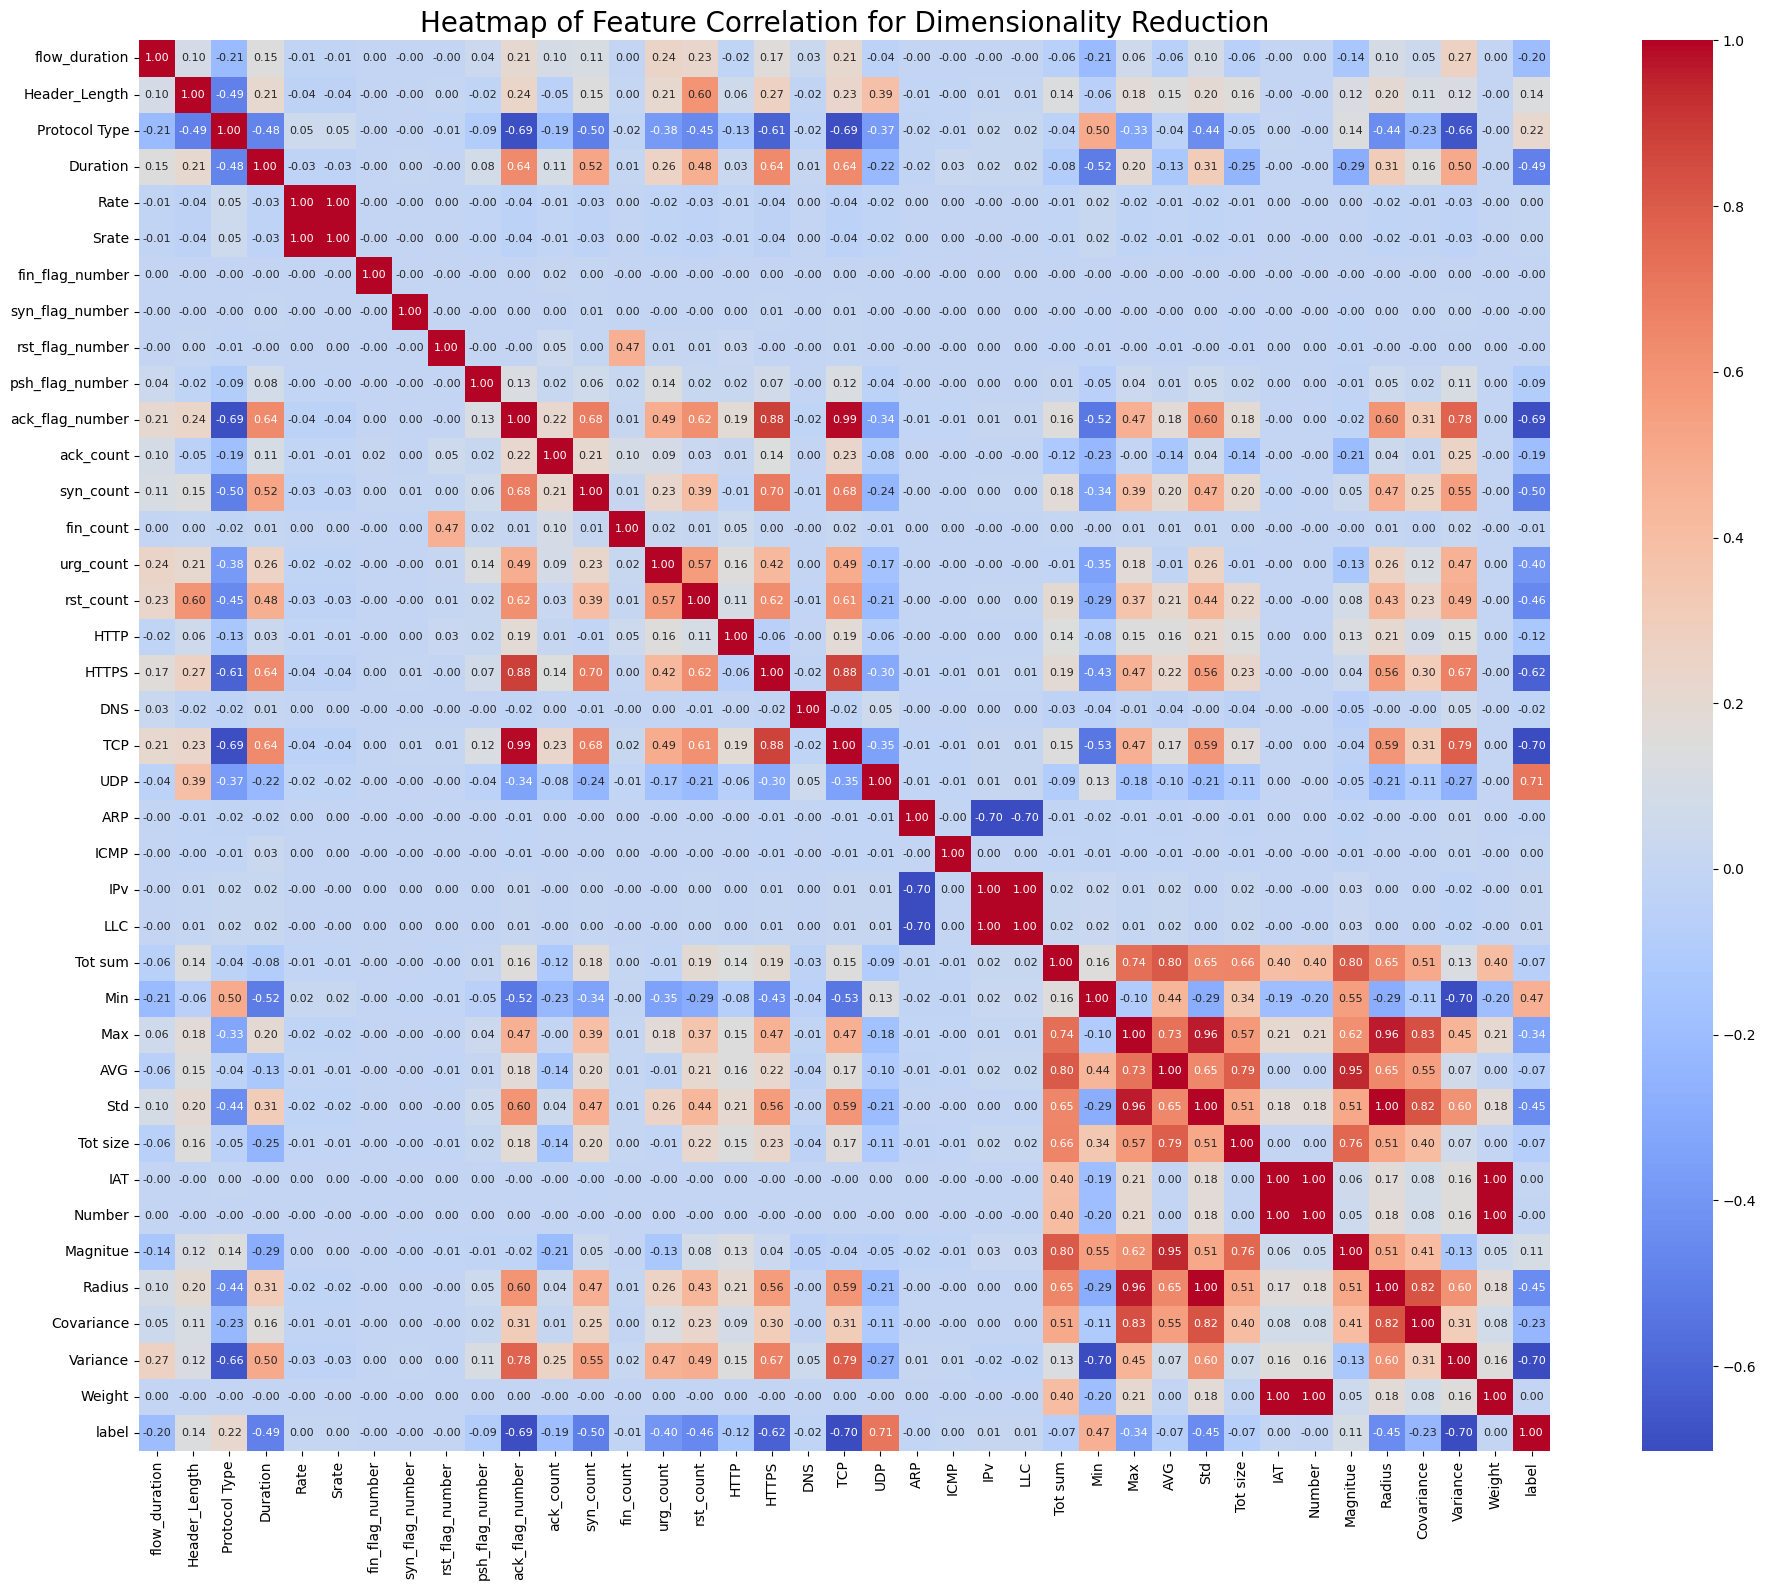

In [12]:



# Gerar o mapa de calor após a exclusão das features que continham apenas valores 0.0

# Recalcular a matriz de correlação
correlation_matrix = novo_dataset.corr()

# Configurar o tamanho da figura maior para melhor visualização
plt.figure(figsize=(20, 16))

# Gerar o mapa de calor
sns.heatmap(
    correlation_matrix,
    annot=True,       # Mostrar os valores no mapa
    fmt=".2f",        # Formatar os valores com duas casas decimais
    cmap="coolwarm",  # Escolher a paleta de cores
    cbar=True,        # Exibir a barra de cores
    square=True,      # Manter células quadradas
    annot_kws={"size": 8}  # Ajustar o tamanho das anotações
)

# Adicionar título 
plt.title("Heatmap of Feature Correlation for Dimensionality Reduction", fontsize=20)
plt.tight_layout()

# Exibir o gráfico
plt.show()

Análise  baixa correlação e alta correlação e valores parecidos de correlação:

In [13]:
# Limite para correlação baixa com o label
low_correlation_threshold = 0.1

# Limite para alta correlação entre features
high_correlation_threshold = 0.85

# Identificar features com baixa correlação com o label
correlation_with_label = correlation_matrix["label"].drop("label")
low_correlation_features = correlation_with_label[correlation_with_label.abs() < low_correlation_threshold].index

print(f"Features com baixa correlação com o label (menor que {low_correlation_threshold}):")
print(low_correlation_features.tolist())

# Identificar pares de features altamente correlacionadas
high_correlation_pairs = []
for feature in correlation_matrix.columns:
    for other_feature in correlation_matrix.columns:
        if feature != other_feature and abs(correlation_matrix[feature][other_feature]) > high_correlation_threshold:
            high_correlation_pairs.append((feature, other_feature))

print("\nPares de features altamente correlacionadas (maior que 0.85):")
print(high_correlation_pairs)

# Opcional: Remover features redundantes ou com baixa correlação
features_to_remove = set(low_correlation_features)
for pair in high_correlation_pairs:
    # Remover apenas uma das features do par (exemplo: manter a primeira)
    if pair[1] not in features_to_remove:
        features_to_remove.add(pair[1])

print("\nFeatures sugeridas para remoção:")
print(features_to_remove)


Features com baixa correlação com o label (menor que 0.1):
['Rate', 'Srate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'fin_count', 'DNS', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'AVG', 'Tot size', 'IAT', 'Number', 'Weight']

Pares de features altamente correlacionadas (maior que 0.85):
[('Rate', 'Srate'), ('Srate', 'Rate'), ('ack_flag_number', 'HTTPS'), ('ack_flag_number', 'TCP'), ('HTTPS', 'ack_flag_number'), ('HTTPS', 'TCP'), ('TCP', 'ack_flag_number'), ('TCP', 'HTTPS'), ('IPv', 'LLC'), ('LLC', 'IPv'), ('Max', 'Std'), ('Max', 'Radius'), ('AVG', 'Magnitue'), ('Std', 'Max'), ('Std', 'Radius'), ('IAT', 'Number'), ('IAT', 'Weight'), ('Number', 'IAT'), ('Number', 'Weight'), ('Magnitue', 'AVG'), ('Radius', 'Max'), ('Radius', 'Std'), ('Weight', 'IAT'), ('Weight', 'Number')]

Features sugeridas para remoção:
{'ICMP', 'Number', 'Srate', 'Rate', 'rst_flag_number', 'TCP', 'Tot sum', 'Tot size', 'HTTPS', 'ack_flag_number', 'syn_flag_number', 'IAT', 'AVG', 'Max'

Remoção das features sugeridas e impressão do novo mapa de calor:

Features restantes no dataset após a remoção:
['flow_duration', 'Duration', 'ack_count', 'syn_count', 'urg_count', 'rst_count', 'HTTP', 'UDP', 'Min', 'Covariance', 'Variance', 'label']


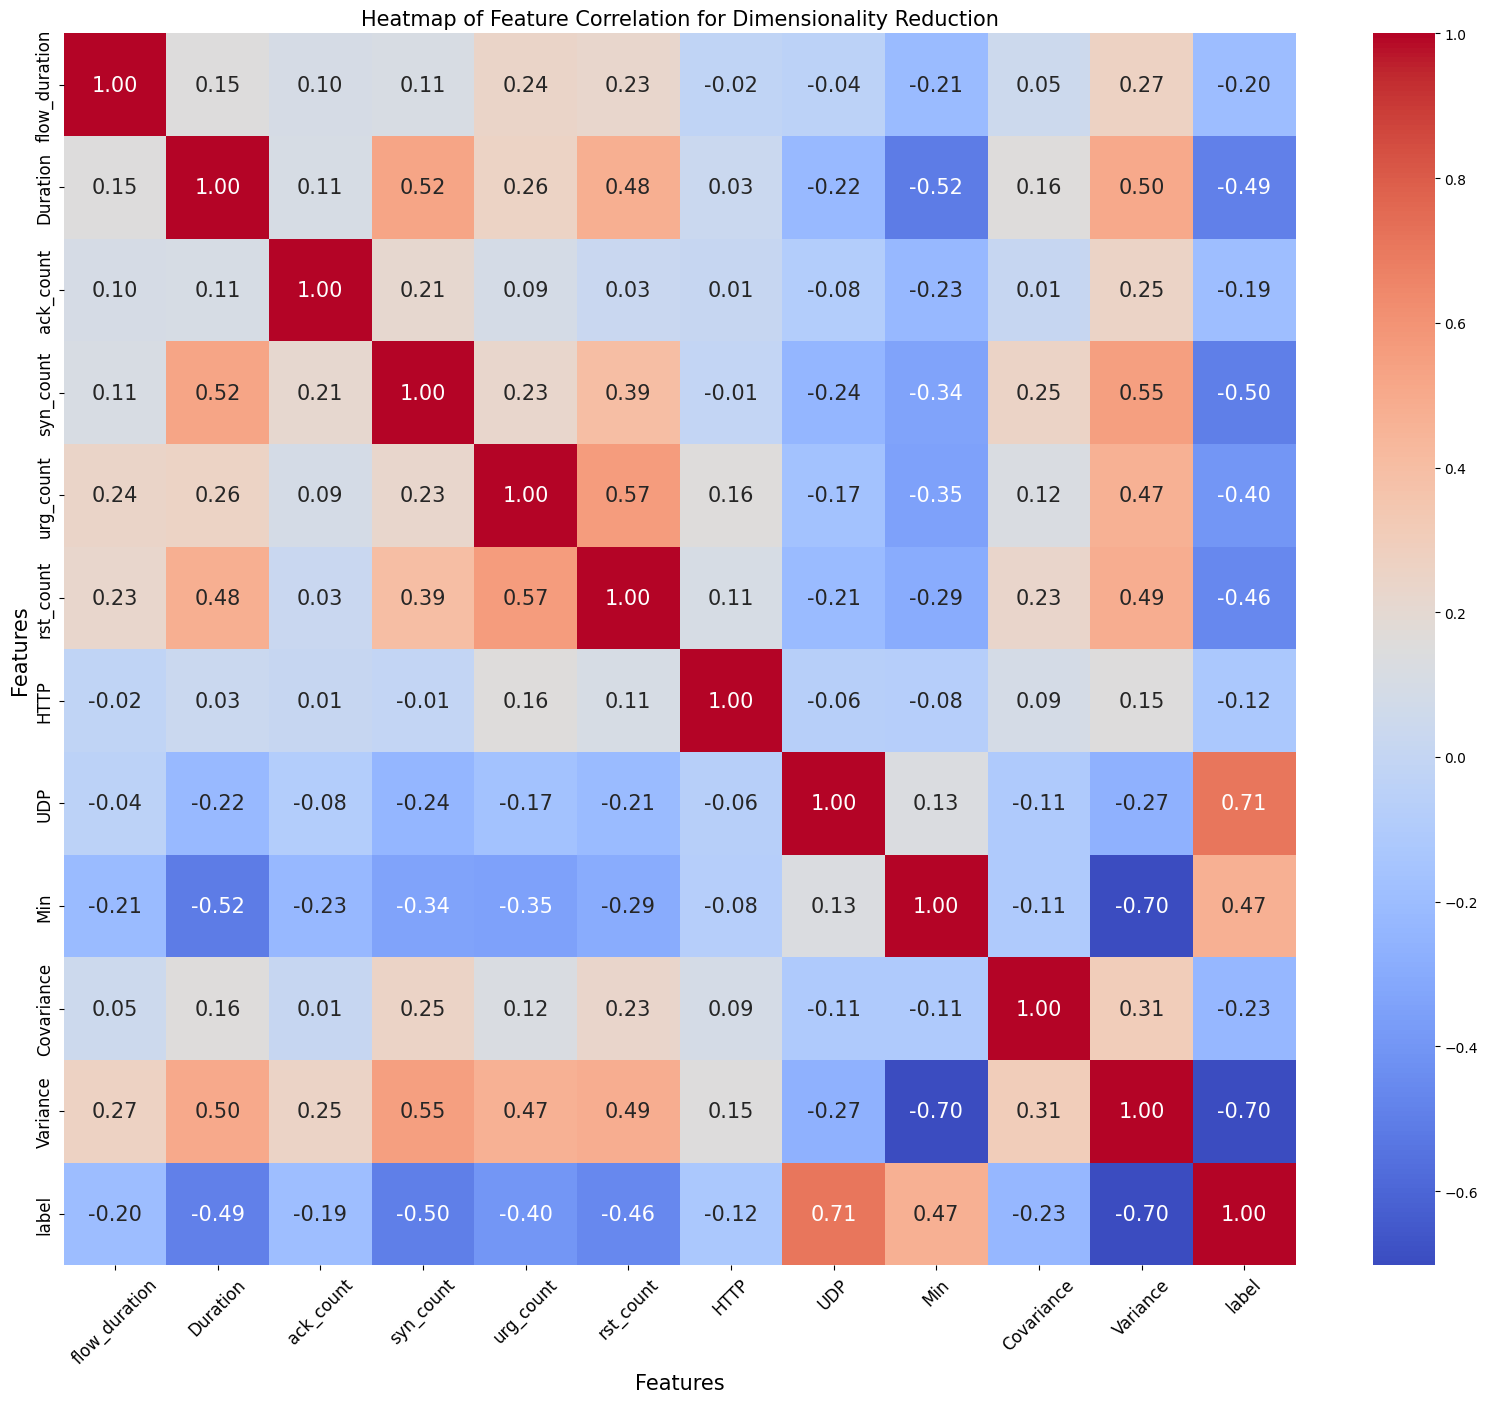

In [14]:
# Remover as features sugeridas do dataset
features_to_remove = {'Radius', 'Srate', 'Max', 'AVG', 'LLC', 'DNS', 'fin_flag_number', 'IPv', 
                      'fin_count', 'Number', 'syn_flag_number', 'ICMP', 'Std', 'Weight', 'IAT', 
                      'Magnitue', 'psh_flag_number', 'ack_flag_number', 'ARP', 'Tot sum', 
                      'Rate', 'TCP', 'HTTPS', 'Tot size', 'rst_flag_number','Protocol Type','Header_Length'}

# Verificar se as features a serem removidas estão no dataset
features_in_dataset = [feature for feature in features_to_remove if feature in novo_dataset.columns]

# Remover as features do dataset
novo_dataset = novo_dataset.drop(columns=features_in_dataset)

# Exibir as features restantes no dataset
print("Features restantes no dataset após a remoção:")
print(novo_dataset.columns.tolist())

# Recalcular o mapa de calor com as features restantes
correlation_matrix_updated = novo_dataset.corr()

# Configurar o tamanho da figura
plt.figure(figsize=(20, 16))

# Gerar o mapa de calor atualizado
sns.heatmap(
    correlation_matrix_updated,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    annot_kws={"size": 15}  # Tamanho das anotações
)

# Ajustar a fonte dos textos externos (título e rótulos dos eixos)
plt.title("Heatmap of Feature Correlation for Dimensionality Reduction", fontsize=15)
plt.xlabel("Features", fontsize=15)
plt.ylabel("Features", fontsize=15)

# Ajustar o tamanho das fontes dos ticks nos eixos X e Y
plt.xticks(fontsize=12, rotation=45)  # Fonte maior e rotação para legibilidade
plt.yticks(fontsize=12)


plt.savefig("heatmap.pdf", format="pdf", bbox_inches='tight')

# Exibir o gráfico
plt.show()





In [ ]:

print("Salvando o dataset com as features restantes em 'dataset_final.csv'...")
novo_dataset.to_csv('dataset_final.csv', index=False)
print("Arquivo salvo com sucesso!")


Salvando o dataset com as features restantes em 'dataset_final.csv'...
Arquivo salvo com sucesso!


GRID SEARCH

In [ ]:


import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    accuracy_score, 
    f1_score        
)

# --- CARREGAMENTO E PREPARAÇÃO DOS DADOS ---

# =====================================================================
# REDUÇÃO PARA 10% DA BASE (SALVA HORAS DE PROCESSAMENTO E POUPA RAM)
# =====================================================================
print("Amostrando 10% da base para o Grid Search...")
df_amostra = novo_dataset.sample(frac=0.10, random_state=42)

X_rf = df_amostra.drop(columns=['label'])
y_rf = df_amostra['label']

X_train_rf, X_temp_rf, y_train_rf, y_temp_rf = train_test_split(X_rf, y_rf, test_size=0.3, stratify=y_rf, random_state=42)
X_val_rf, X_test_rf, y_val_rf, y_test_rf = train_test_split(X_temp_rf, y_temp_rf, test_size=0.5, stratify=y_temp_rf, random_state=42)

scaler_rf = StandardScaler()
X_train_scaled_rf = scaler_rf.fit_transform(X_train_rf)
X_test_scaled_rf = scaler_rf.transform(X_test_rf)


# --- OTIMIZAÇÃO, TREINO E AVALIAÇÃO COM GRIDSEARCHCV ---

# 1. Definição da grade de parâmetros a testar
param_grid_rf = {
    'n_estimators':[50, 100, 200], 
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Criação do objeto GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=3,  # 3-fold cross-validation
    scoring='f1_macro', # Métrica alvo para otimização
    n_jobs=-1, # Usar todos os 12 threads do Ryzen
    verbose=2
)

# 3. Execução da busca 
print("Iniciando o Grid Search para o Random Forest...")
start_grid_time = time.time()
grid_search_rf.fit(X_train_scaled_rf, y_train_rf)
grid_duration = time.time() - start_grid_time
print(f"Grid Search concluído em {grid_duration/60:.2f} minutos.")

# 4. Extração do melhor modelo e seus parâmetros
print("\nMelhores parâmetros encontrados:")
print(grid_search_rf.best_params_)
best_model_rf = grid_search_rf.best_estimator_


# 5. Inferência e avaliação final no conjunto de teste (dos 10%)
print("\nIniciando a inferência no conjunto de teste com o melhor modelo...")
start_inference_time = time.time()
y_test_pred_rf = best_model_rf.predict(X_test_scaled_rf)
inference_time_rf = time.time() - start_inference_time
print(f"Inferência concluída em {inference_time_rf:.4f} segundos.")


# --- CÁLCULO E EXIBIÇÃO DAS MÉTRICAS FINAIS ---

test_accuracy_rf = accuracy_score(y_test_rf, y_test_pred_rf)
test_balanced_accuracy_rf = balanced_accuracy_score(y_test_rf, y_test_pred_rf)
test_f1_rf = f1_score(y_test_rf, y_test_pred_rf, average='macro') 
test_kappa_rf = cohen_kappa_score(y_test_rf, y_test_pred_rf)
test_mcc_rf = matthews_corrcoef(y_test_rf, y_test_pred_rf)

print("\n" + "="*40)
print("  Resultados Finais - Melhor Modelo Random Forest (Amostra 10%)")
print("="*40)

print(f"\n--- Tempos ---")
print(f"Tempo Total de Otimização (Grid Search): {grid_duration:.2f} segundos")
print(f"Tempo de Inferência: {inference_time_rf:.4f} segundos")

print(f"\n--- Métricas de Desempenho (Conjunto de Teste) ---")
print(f"Acurácia: {test_accuracy_rf:.4f}")
print(f"Acurácia Balanceada: {test_balanced_accuracy_rf:.4f}")
print(f"F1-Score (Macro): {test_f1_rf:.4f}")
print(f"Kappa de Cohen: {test_kappa_rf:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {test_mcc_rf:.4f}")

print("\n--- Relatório de Classificação por Classe ---")
print(classification_report(y_test_rf, y_test_pred_rf))
print("="*40)

Amostrando 10% da base para o Grid Search...
Iniciando o Grid Search para o Random Forest...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  27.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  28.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  30.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  30.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  31.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  32.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  54.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  55.7s
[CV] END max_depth=None, m

Valores do GRID SEARCH:

In [14]:
# --- Script Final para Treino e Avaliação do Melhor Modelo Random Forest ---

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    f1_score
)

# --- CARREGAMENTO E PREPARAÇÃO DOS DADOS (permanece igual) ---
# novo_dataset = pd.read_csv('seu_dataset_tratado.csv')

X_rf = novo_dataset.drop(columns=['label'])
y_rf = novo_dataset['label']

X_train_rf, X_temp_rf, y_train_rf, y_temp_rf = train_test_split(X_rf, y_rf, test_size=0.3, stratify=y_rf, random_state=42)
X_val_rf, X_test_rf, y_val_rf, y_test_rf = train_test_split(X_temp_rf, y_temp_rf, test_size=0.5, stratify=y_temp_rf, random_state=42)

scaler_rf = StandardScaler()
X_train_scaled_rf = scaler_rf.fit_transform(X_train_rf)
X_test_scaled_rf = scaler_rf.transform(X_test_rf)


# --- TREINAMENTO DO MODELO OTIMIZADO ---

# 1. Definir os melhores parâmetros encontrados pelo GridSearchCV
best_params_rf = {
    'max_depth': 20,
    'min_samples_leaf': 1,
    'min_samples_split': 5,
    'n_estimators': 200,
    'random_state': 42, # Manter para reprodutibilidade
    'n_jobs': 6      # Usar todos os processadores para acelerar o treino
}

# 2. Criar e treinar o modelo final com os melhores parâmetros
model_rf_final = RandomForestClassifier(**best_params_rf)

print("Iniciando o treinamento do modelo Random Forest final...")
start_train_time = time.time()
model_rf_final.fit(X_train_scaled_rf, y_train_rf)
training_time_rf = time.time() - start_train_time
print(f"Treinamento concluído em {training_time_rf:.4f} segundos.")


# --- INFERÊNCIA NO CONJUNTO DE TESTE ---
print("\nIniciando a inferência no conjunto de teste...")
start_inference_time = time.time()
y_test_pred_rf = model_rf_final.predict(X_test_scaled_rf)
inference_time_rf = time.time() - start_inference_time
print(f"Inferência concluída em {inference_time_rf:.4f} segundos.")


# --- CÁLCULO E EXIBIÇÃO DAS MÉTRICAS FINAIS ---

test_accuracy_rf = accuracy_score(y_test_rf, y_test_pred_rf)
test_balanced_accuracy_rf = balanced_accuracy_score(y_test_rf, y_test_pred_rf)
test_f1_rf = f1_score(y_test_rf, y_test_pred_rf, average='macro')
test_kappa_rf = cohen_kappa_score(y_test_rf, y_test_pred_rf)
test_mcc_rf = matthews_corrcoef(y_test_rf, y_test_pred_rf)

print("\n" + "="*40)
print("  Resultados Finais - Modelo Random Forest Otimizado")
print("="*40)

print(f"\n--- Tempos ---")
print(f"Tempo de Treinamento: {training_time_rf:.4f} segundos")
print(f"Tempo de Inferência: {inference_time_rf:.4f} segundos")

print(f"\n--- Métricas de Desempenho (Conjunto de Teste) ---")
print(f"Acurácia: {test_accuracy_rf:.4f}")
print(f"Acurácia Balanceada: {test_balanced_accuracy_rf:.4f}")
print(f"F1-Score (Macro): {test_f1_rf:.4f}")
print(f"Kappa de Cohen: {test_kappa_rf:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {test_mcc_rf:.4f}")

print("\n--- Relatório de Classificação por Classe ---")
print(classification_report(y_test_rf, y_test_pred_rf))
print("="*40)

Iniciando o treinamento do modelo Random Forest final...
Treinamento concluído em 221.6784 segundos.

Iniciando a inferência no conjunto de teste...
Inferência concluída em 1.7499 segundos.

  Resultados Finais - Modelo Random Forest Otimizado

--- Tempos ---
Tempo de Treinamento: 221.6784 segundos
Tempo de Inferência: 1.7499 segundos

--- Métricas de Desempenho (Conjunto de Teste) ---
Acurácia: 0.9668
Acurácia Balanceada: 0.9632
F1-Score (Macro): 0.9638
Kappa de Cohen: 0.9555
Matthews Correlation Coefficient (MCC): 0.9555

--- Relatório de Classificação por Classe ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    129062
           1       0.93      0.95      0.94    116647
           2       0.93      0.91      0.92     88297
           3       1.00      1.00      1.00    104677

    accuracy                           0.97    438683
   macro avg       0.96      0.96      0.96    438683
weighted avg       0.97      0.97      0.97 

In [ ]:
print("\nGerando SHAP com amostra...")

# Converter para DataFrame com colunas
X_test_scaled_rf_df = pd.DataFrame(X_test_scaled_rf, columns=X_rf.columns)

# Amostra de 500 registros para acelerar
X_test_sample = X_test_scaled_rf_df.sample(500, random_state=42)

explainer_rf = shap.TreeExplainer(model_rf_final)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# Gráfico de barras (mais rápido)
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test_sample, plot_type="bar")
else:
    shap.summary_plot(shap_values_rf, X_test_sample, plot_type="bar")

     


Gerando SHAP com amostra...


Plotagem da matriz de confusão RF:

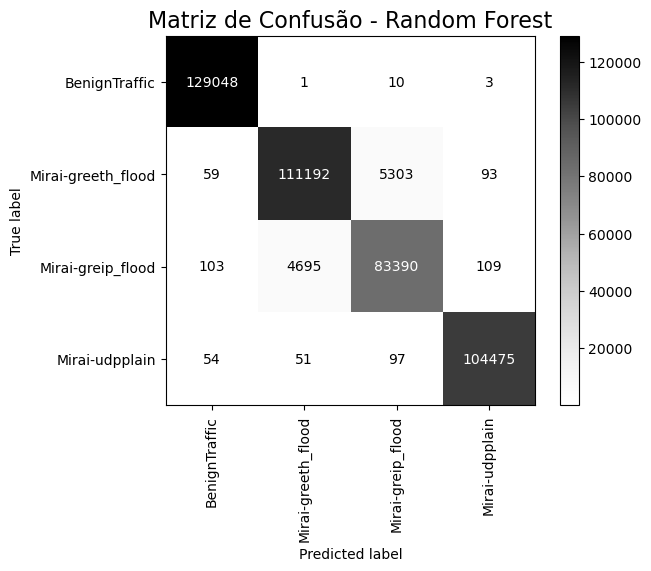

In [14]:

# Recuperar o LabelEncoder do dicionário label_encoders
# Supondo que o nome da coluna original do label é 'label'
le_label = label_encoders['label']

# Gerar a matriz de confusão para o modelo Random Forest
conf_matrix_rf = confusion_matrix(y_test_rf, y_test_pred_rf)

# Recuperar os nomes originais das classes para o Random Forest
class_names_rf = [str(label) for label in le_label.inverse_transform(range(len(le_label.classes_)))]

# Exibir a matriz de confusão para o modelo LightGBM
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=class_names_rf)
disp_rf.plot(cmap="Greys", xticks_rotation='vertical', values_format=".0f")

# Adicionar título
plt.title("Matriz de Confusão - Random Forest", fontsize=16)

# Exibir o gráfico
plt.savefig("matriz_confusao_rf.pdf", bbox_inches='tight')

GRID SEARCH LGBM:

In [ ]:
# --- Script Completo para Otimização e Avaliação do LightGBM ---

import time
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from lightgbm import LGBMClassifier  # Importar o classificador compatível com Scikit-learn
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    accuracy_score,
    f1_score
)

# Ocultar warnings de C++ do LightGBM para manter o terminal limpo
warnings.filterwarnings('ignore')

# =====================================================================
# REDUÇÃO PARA 10% DA BASE (SALVA HORAS DE PROCESSAMENTO)
# =====================================================================
print("Amostrando 10% da base para o Grid Search do LightGBM...")
df_amostra = novo_dataset.sample(frac=0.10, random_state=42)

X_lgbm = df_amostra.drop(columns=['label'])
y_lgbm = df_amostra['label']

label_encoder_lgbm = LabelEncoder()
y_lgbm_encoded = label_encoder_lgbm.fit_transform(y_lgbm)

X_train_lgbm, X_temp_lgbm, y_train_lgbm, y_temp_lgbm = train_test_split(X_lgbm, y_lgbm_encoded, test_size=0.3, stratify=y_lgbm_encoded, random_state=42)
X_val_lgbm, X_test_lgbm, y_val_lgbm, y_test_lgbm = train_test_split(X_temp_lgbm, y_temp_lgbm, test_size=0.5, stratify=y_temp_lgbm, random_state=42)

# Normalizar apenas colunas numéricas
numerical_columns = X_train_lgbm.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train_lgbm[numerical_columns] = scaler.fit_transform(X_train_lgbm[numerical_columns])
X_test_lgbm[numerical_columns] = scaler.transform(X_test_lgbm[numerical_columns])


# --- OTIMIZAÇÃO, TREINO E AVALIAÇÃO COM GRIDSEARCHCV ---

# 1. Definição da grade de parâmetros a testar
param_grid_lgbm = {
    'n_estimators':[100,200,300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':[31, 50, 100],
    'max_depth': [-1, 10, 20]
}

# 2. Criação do objeto GridSearchCV
grid_search_lgbm = GridSearchCV(
    # usa todos os 12 núcleos do Ryzen
    estimator=LGBMClassifier(random_state=42, objective='multiclass', n_jobs=-1, verbose=-1),
    param_grid=param_grid_lgbm,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,  
    verbose=2
)

# 3. Execução da busca (Treinamento)
print("="*50)
print("Iniciando o Grid Search para o LightGBM...")
start_grid_time = time.time()

grid_search_lgbm.fit(X_train_lgbm, y_train_lgbm)

duration = time.time() - start_grid_time
print(f"Grid Search concluído em {duration/60:.2f} minutos.")
print("="*50)

# 4. Análise dos resultados do Grid Search
print("\nMelhores parâmetros encontrados:")
print(grid_search_lgbm.best_params_)

print(f"\nMelhor score (F1-Macro CV): {grid_search_lgbm.best_score_:.4f}")

# 5. Avaliação final no conjunto de teste (dos 10%)
print("\n" + "="*50)
print("Avaliando o melhor modelo LGBM no conjunto de teste...")

start_inference_time = time.time()
y_test_pred_lgbm_best = grid_search_lgbm.predict(X_test_lgbm)
inference_time_lgbm = time.time() - start_inference_time
print(f"Inferência concluída em {inference_time_lgbm:.4f} segundos.")

# --- CÁLCULO E EXIBIÇÃO DAS MÉTRICAS FINAIS ---

test_accuracy_lgbm = accuracy_score(y_test_lgbm, y_test_pred_lgbm_best)
test_balanced_accuracy_lgbm = balanced_accuracy_score(y_test_lgbm, y_test_pred_lgbm_best)
test_f1_lgbm = f1_score(y_test_lgbm, y_test_pred_lgbm_best, average='macro')
test_kappa_lgbm = cohen_kappa_score(y_test_lgbm, y_test_pred_lgbm_best)
test_mcc_lgbm = matthews_corrcoef(y_test_lgbm, y_test_pred_lgbm_best)

print("\n" + "="*40)
print("  Resultados Finais - Melhor Modelo LightGBM (Amostra 10%)")
print("="*40)

print(f"\n--- Tempos ---")
print(f"Tempo Total de Otimização (Grid Search): {duration:.2f} segundos")
print(f"Tempo de Inferência: {inference_time_lgbm:.4f} segundos")

print(f"\n--- Métricas de Desempenho (Conjunto de Teste) ---")
print(f"Acurácia: {test_accuracy_lgbm:.4f}")
print(f"Acurácia Balanceada: {test_balanced_accuracy_lgbm:.4f}")
print(f"F1-Score (Macro): {test_f1_lgbm:.4f}")
print(f"Kappa de Cohen: {test_kappa_lgbm:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {test_mcc_lgbm:.4f}")

print("\n--- Relatório de Classificação por Classe ---")
class_names_lgbm = [str(label) for label in label_encoder_lgbm.classes_]
print(classification_report(y_test_lgbm, y_test_pred_lgbm_best, target_names=class_names_lgbm))
print("="*40)

Amostrando 10% da base para o Grid Search do LightGBM...
Iniciando o Grid Search para o LightGBM...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=31; total time=   7.5s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=31; total time=   5.8s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=31; total time=   5.3s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=50; total time=   6.1s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=50; total time=   5.6s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=50; total time=   9.3s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=100; total time=  11.8s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=100; total time=   7.8s
[CV] END learning_rate=0.01, max_depth=-1, n_estimators=100, num_leaves=100;

LGBM CUSTOM FINAL:


Iniciando o treinamento do modelo LightGBM DEFINITIVO...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.148857 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2037
[LightGBM] [Info] Number of data points in the train set: 2047182, number of used features: 11
[LightGBM] [Info] Start training from score -1.223489
[LightGBM] [Info] Start training from score -1.324620
[LightGBM] [Info] Start training from score -1.603065
[LightGBM] [Info] Start training from score -1.432903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Treinamento concluído em 660.3046 segundos.

Iniciando a inferência no conjunto de teste...
Inferência concluída em 6.9060 segundos.

  Resultados Oficiais - Modelo LightGBM (100% da Base)

--- Tempos ---
Tempo de Treinamento: 660.3046 segundos
Tempo de Inferência: 6.9060 segundos

--- Métricas de Desempenho (Conjunto de Teste) ---
Acurácia: 0.9765
Acurácia B

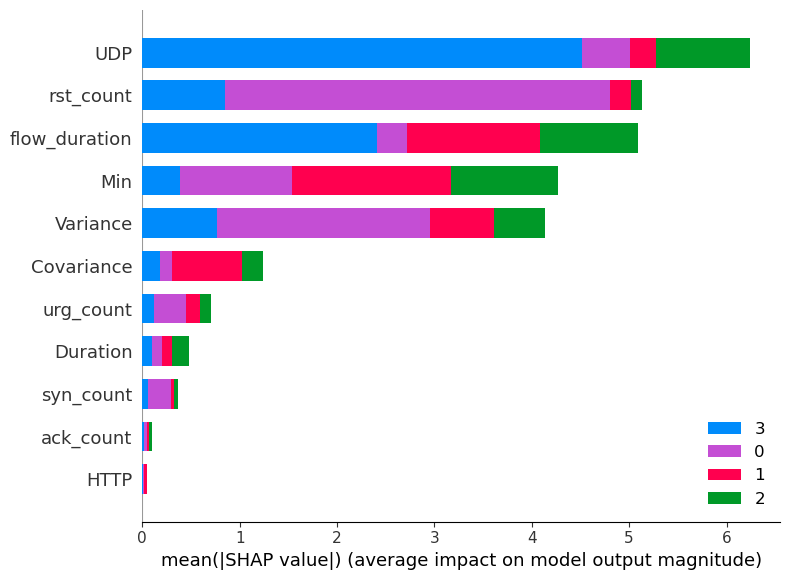

Processo finalizado com sucesso!

Salvando artefatos para inferência em produção...
[+] Modelo LightGBM salvo como 'seu_modelo_lightgbm.pkl'
[+] StandardScaler salvo como 'scaler_lgbm.pkl'
[+] LabelEncoder salvo como 'label_encoder_lgbm.pkl'


In [ ]:


import time
import joblib
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from lightgbm import LGBMClassifier  # Import the scikit-learn compatible classifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef
)
import shap

# Ocultar warnings do LightGBM
warnings.filterwarnings('ignore')

X_lgbm = novo_dataset.drop(columns=['label'])
y_lgbm = novo_dataset['label']

label_encoder_lgbm = LabelEncoder()
y_lgbm_encoded = label_encoder_lgbm.fit_transform(y_lgbm)

X_train_lgbm, X_temp_lgbm, y_train_lgbm, y_temp_lgbm = train_test_split(X_lgbm, y_lgbm_encoded, test_size=0.3, stratify=y_lgbm_encoded, random_state=42)
X_val_lgbm, X_test_lgbm, y_val_lgbm, y_test_lgbm = train_test_split(X_temp_lgbm, y_temp_lgbm, test_size=0.5, stratify=y_temp_lgbm, random_state=42)

# Normalizar apenas colunas numéricas
numerical_columns = X_train_lgbm.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train_lgbm[numerical_columns] = scaler.fit_transform(X_train_lgbm[numerical_columns])
X_test_lgbm[numerical_columns] = scaler.transform(X_test_lgbm[numerical_columns])


# --- TRAINING THE OPTIMIZED MODEL (100% DOS DADOS) ---

# 1. Os melhores hiperparâmetros recém-descobertos pelo Grid Search
best_params_lgbm = {
    'learning_rate': 0.05,
    'max_depth': 10,
    'n_estimators': 300,
    'num_leaves': 100,
    'random_state': 42,
    'objective': 'multiclass',
    'n_jobs': -1  # Usa os 12 threads do seu Ryzen para voar no treinamento
}

# 2. Create and train the final model with the best parameters
model_lgbm_final = LGBMClassifier(**best_params_lgbm)

print("="*50)
print("Iniciando o treinamento do modelo LightGBM DEFINITIVO...")
start_train_time = time.time()
model_lgbm_final.fit(X_train_lgbm, y_train_lgbm)
training_time_lgbm = time.time() - start_train_time
print(f"Treinamento concluído em {training_time_lgbm:.4f} segundos.")


# --- INFERENCE ON THE TEST SET ---
print("\nIniciando a inferência no conjunto de teste...")
start_inference_time = time.time()
y_test_pred_lgbm = model_lgbm_final.predict(X_test_lgbm)
inference_time_lgbm = time.time() - start_inference_time
print(f"Inferência concluída em {inference_time_lgbm:.4f} segundos.")


# --- CALCULATION AND DISPLAY OF FINAL METRICS ---

test_accuracy_lgbm = accuracy_score(y_test_lgbm, y_test_pred_lgbm)
test_balanced_accuracy_lgbm = balanced_accuracy_score(y_test_lgbm, y_test_pred_lgbm)
test_f1_lgbm = f1_score(y_test_lgbm, y_test_pred_lgbm, average='macro')
test_kappa_lgbm = cohen_kappa_score(y_test_lgbm, y_test_pred_lgbm)
test_mcc_lgbm = matthews_corrcoef(y_test_lgbm, y_test_pred_lgbm)

print("\n" + "="*50)
print("  Resultados Oficiais - Modelo LightGBM (100% da Base)")
print("="*50)

print(f"\n--- Tempos ---")
print(f"Tempo de Treinamento: {training_time_lgbm:.4f} segundos")
print(f"Tempo de Inferência: {inference_time_lgbm:.4f} segundos")

print(f"\n--- Métricas de Desempenho (Conjunto de Teste) ---")
print(f"Acurácia: {test_accuracy_lgbm:.4f}")
print(f"Acurácia Balanceada: {test_balanced_accuracy_lgbm:.4f}")
print(f"F1-Score (Macro): {test_f1_lgbm:.4f}")
print(f"Kappa de Cohen: {test_kappa_lgbm:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {test_mcc_lgbm:.4f}")

print("\n--- Relatório de Classificação por Classe ---")
class_names_lgbm = [str(label) for label in label_encoder_lgbm.classes_]
print(classification_report(y_test_lgbm, y_test_pred_lgbm, target_names=class_names_lgbm))
print("="*50)

# --- SHAP EXPLAINABILITY FOR LightGBM ---

print("\nGerando o Gráfico SHAP para o modelo limpo...")

# Create a TreeExplainer for the final trained model
explainer_lgbm = shap.TreeExplainer(model_lgbm_final)

# Create a sample of the test set for faster SHAP value calculation
X_test_sample_lgbm = X_test_lgbm.sample(n=min(500, len(X_test_lgbm)), random_state=42)

# Calculate SHAP values
shap_values_lgbm = explainer_lgbm.shap_values(X_test_sample_lgbm)

# Summary bar plot
shap.summary_plot(shap_values_lgbm, X_test_sample_lgbm, plot_type="bar", class_names=class_names_lgbm)
print("Processo finalizado com sucesso!")


# --- SALVANDO O MODELO E TRANSFORMADORES PARA A NÉVOA (FOG) ---
print("\n" + "="*50)
print("Salvando artefatos para inferência em produção...")

# 1. Salvar o modelo LightGBM treinado
joblib.dump(model_lgbm_final, 'lightgbm.pkl')
print("[+] Modelo LightGBM salvo como 'lightgbm.pkl'")

# 2. Salvar o Scaler (CRÍTICO: O testbed 5G precisa escalar os dados do mesmo jeito)
joblib.dump(scaler, 'scaler_lgbm.pkl')
print("[+] StandardScaler salvo como 'scaler_lgbm.pkl'")

# 3. Salvar o Label Encoder (Para sabermos os nomes das classes na predição)
joblib.dump(label_encoder_lgbm, 'label_encoder_lgbm.pkl')
print("[+] LabelEncoder salvo como 'label_encoder_lgbm.pkl'")
print("="*50)

NOVO COM MEDIÇÃO DE TREINO E DE INFERENCIA:

In [14]:
# --- Script Completo para Treino e Avaliação do LightGBM ---

import time
import lightgbm as lgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,        # Importado
    matthews_corrcoef         # Importado
)

# --- CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
# Assumindo que a variável 'novo_dataset' (um DataFrame pandas) já foi carregada
# Exemplo:
# novo_dataset = pd.read_csv('seu_dataset_tratado.csv')

# Preparação dos dados
X_lightgbm = novo_dataset.drop(columns=['label'])
y_lightgbm = novo_dataset['label']

label_encoder_lgbm = LabelEncoder()
y_lightgbm_encoded = label_encoder_lgbm.fit_transform(y_lightgbm)

X_train_lgbm, X_temp_lgbm, y_train_lgbm, y_temp_lgbm = train_test_split(X_lightgbm, y_lightgbm_encoded, test_size=0.3, stratify=y_lightgbm_encoded, random_state=42)
X_val_lgbm, X_test_lgbm, y_val_lgbm, y_test_lgbm = train_test_split(X_temp_lgbm, y_temp_lgbm, test_size=0.5, stratify=y_temp_lgbm, random_state=42)

# Normalizar apenas colunas numéricas (exemplo)
numerical_columns = X_train_lgbm.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train_lgbm[numerical_columns] = scaler.fit_transform(X_train_lgbm[numerical_columns])
X_val_lgbm[numerical_columns] = scaler.transform(X_val_lgbm[numerical_columns])
X_test_lgbm[numerical_columns] = scaler.transform(X_test_lgbm[numerical_columns])


train_data_lgbm = lgb.Dataset(X_train_lgbm, label=y_train_lgbm)
val_data_lgbm = lgb.Dataset(X_val_lgbm, label=y_val_lgbm, reference=train_data_lgbm)

params_lgbm = {
    'objective': 'multiclass',
    'num_class': len(label_encoder_lgbm.classes_),
    'learning_rate': 0.1,
    'metric': 'multi_logloss',
    'random_state': 42
}

# --- TREINAMENTO DO MODELO ---
print("Iniciando o treinamento do modelo LightGBM...")
start_train_time = time.time()
model_lgbm = lgb.train(
    params_lgbm,
    train_data_lgbm,
    valid_sets=[val_data_lgbm],
    num_boost_round=100
)
training_time_lgbm = time.time() - start_train_time
print(f"Treinamento concluído em {training_time_lgbm:.4f} segundos.")


# --- INFERÊNCIA NO CONJUNTO DE TESTE ---
print("\nIniciando a inferência no conjunto de teste...")
start_inference_time = time.time()
y_test_pred_proba_lgbm = model_lgbm.predict(X_test_lgbm)
y_test_pred_lgbm = y_test_pred_proba_lgbm.argmax(axis=1)
inference_time_lgbm = time.time() - start_inference_time
print(f"Inferência concluída em {inference_time_lgbm:.4f} segundos.")


# --- CÁLCULO DE MÉTRICAS COMPLETAS ---
test_accuracy_lgbm = accuracy_score(y_test_lgbm, y_test_pred_lgbm)
test_balanced_accuracy_lgbm = balanced_accuracy_score(y_test_lgbm, y_test_pred_lgbm)
test_f1_lgbm = f1_score(y_test_lgbm, y_test_pred_lgbm, average='weighted')
test_kappa_lgbm = cohen_kappa_score(y_test_lgbm, y_test_pred_lgbm)
test_mcc_lgbm = matthews_corrcoef(y_test_lgbm, y_test_pred_lgbm)


# --- EXIBIÇÃO DOS RESULTADOS ---
print("\n" + "="*40)
print("  Resultados Finais - LightGBM")
print("="*40)

print(f"\n--- Tempos ---")
print(f"Tempo de Treinamento: {training_time_lgbm:.4f} segundos")
print(f"Tempo de Inferência: {inference_time_lgbm:.4f} segundos")

print(f"\n--- Métricas de Desempenho (Conjunto de Teste) ---")
print(f"Acurácia: {test_accuracy_lgbm:.4f}")
print(f"Acurácia Balanceada: {test_balanced_accuracy_lgbm:.4f}")
print(f"F1-Score (Ponderado): {test_f1_lgbm:.4f}")
print(f"Kappa de Cohen: {test_kappa_lgbm:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {test_mcc_lgbm:.4f}")

print("\n--- Relatório de Classificação por Classe ---")
class_names_lgbm = [str(label) for label in label_encoder_lgbm.classes_]
print(classification_report(y_test_lgbm, y_test_pred_lgbm, target_names=class_names_lgbm))
print("="*40)

Iniciando o treinamento do modelo LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2292
[LightGBM] [Info] Number of data points in the train set: 2047182, number of used features: 12
[LightGBM] [Info] Start training from score -1.223489
[LightGBM] [Info] Start training from score -1.324620
[LightGBM] [Info] Start training from score -1.603065
[LightGBM] [Info] Start training from score -1.432903
Treinamento concluído em 50.2575 segundos.

Iniciando a inferência no conjunto de teste...
Inferência concluída em 1.0315 segundos.

  Resultados Finais - LightGBM

--- Tempos ---
Tempo de Treinamento: 50.2575 segundos
Tempo de Inferência: 1.0315 segundos

--- Métricas de Desempenho (Conjunto de Teste) ---
Acurácia: 0.9746
Acurácia Balanceada: 0.9727
F1-Score (Ponderado): 0.9746
K

📌 Mapeamento de classes reais:
[0] → BenignTraffic
[1] → Mirai-greeth_flood
[2] → Mirai-greip_flood
[3] → Mirai-udpplain

🔍 Classe alvo: 0 → BenignTraffic
✅ Gráfico BARRA CINZA salvo como: shap_global_BenignTraffic_cinza.png


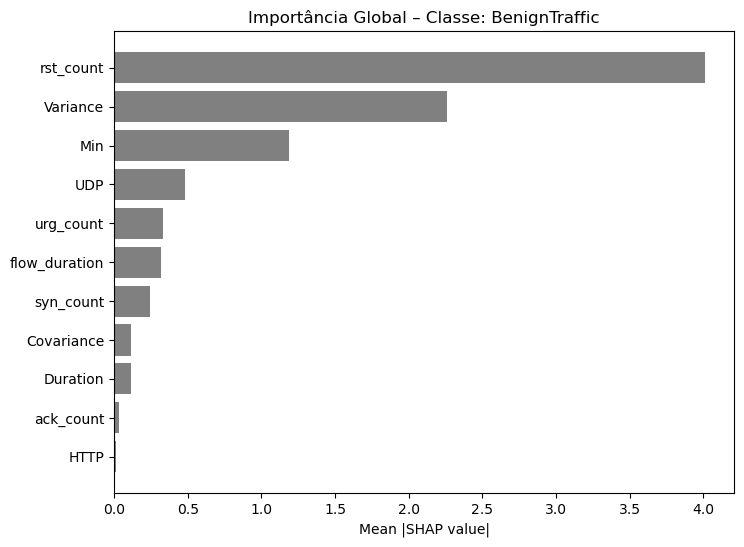

In [19]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ========================
# ✅ 1) Mapeamento manual
# ========================

class_map = {
    0: "BenignTraffic",
    1: "Mirai-greeth_flood",
    2: "Mirai-greip_flood",
    3: "Mirai-udpplain"
}

print("="*40)
print("📌 Mapeamento de classes reais:")
print("="*40)
for k, v in class_map.items():
    print(f"[{k}] → {v}")
print("="*40)

# ==============================
# ✅ 2) Amostra SHAP
# ==============================

amostras = 2000
X_sample_lgbm = pd.DataFrame(X_test_lgbm[:amostras], columns=X_lgbm.columns)

# =========================================
# ✅ 3) Explicador SHAP com API moderna
# =========================================

explainer = shap.Explainer(model_lgbm_final)
shap_values = explainer(X_sample_lgbm)

# ==================================
# ✅ 4) Definir classe alvo
# ==================================

classe_alvo = 0
classe_nome = class_map[classe_alvo]

print(f"\n🔍 Classe alvo: {classe_alvo} → {classe_nome}")

# ===========================================
# ✅ 5) Pegar médias absolutas SHAP manualmente
# ===========================================

mean_abs_shap = np.abs(shap_values.values[:, :, classe_alvo]).mean(axis=0)
feature_names = X_sample_lgbm.columns

# Ordenar por importância
order = np.argsort(mean_abs_shap)[::-1]
mean_abs_shap_sorted = mean_abs_shap[order]
feature_names_sorted = feature_names[order]

# ==================================
# ✅ 6) Plotar gráfico BARRA CINZA
# ==================================

plt.figure(figsize=(8, 6))
plt.barh(feature_names_sorted, mean_abs_shap_sorted, color='gray')
plt.xlabel("Mean |SHAP value|")
plt.title(f"Importância Global – Classe: {classe_nome}")
plt.gca().invert_yaxis()

# Salvar figura em alta resolução
nome_fig = f"shap_global_{classe_nome}_cinza.png"
plt.savefig(nome_fig, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico BARRA CINZA salvo como: {nome_fig}")

plt.show()


In [23]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Mapeamento manual
class_map = {
    0: "Benigno",
    1: "Mirai-greeth_flood",
    2: "Mirai-greip_flood",
    3: "Mirai-udpplain"
}

# ========================
# ✅ Amostra SHAP
# ========================
amostras = 2000
X_sample_lgbm = pd.DataFrame(X_test_lgbm[:amostras], columns=X_lgbm.columns)

# ✅ Criar explicador e calcular
explainer = shap.Explainer(model_lgbm)
shap_values = explainer(X_sample_lgbm)

# ================================
# ✅ Preparar subplots 2x2
# ================================
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

# ✅ Para cada classe
for classe_alvo in range(4):
    classe_nome = class_map[classe_alvo]

    # Média |SHAP| para classe
    mean_abs_shap = np.abs(shap_values.values[:, :, classe_alvo]).mean(axis=0)
    feature_names = X_sample_lgbm.columns

    # Ordenar top 10
    order = np.argsort(mean_abs_shap)[::-1]
    top_n = 10
    mean_abs_shap_sorted = mean_abs_shap[order][:top_n]
    feature_names_sorted = feature_names[order][:top_n]

    # Plotar barras horizontais
    axs[classe_alvo].barh(feature_names_sorted, mean_abs_shap_sorted, color='gray')
    axs[classe_alvo].invert_yaxis()
    axs[classe_alvo].set_title(f"Class {classe_alvo}: {classe_nome}")
    axs[classe_alvo].set_xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.savefig("shap_comparativo_cinza.pdf", format="pdf", bbox_inches='tight')
plt.show()


NameError: name 'model_lgbm' is not defined


=== BenignTraffic ===
rst_count            | Real Mean:    254.383 | Mean |SHAP|: 3.91628
Variance             | Real Mean:      0.343 | Mean |SHAP|: 2.22450
Min                  | Real Mean:    408.227 | Mean |SHAP|: 1.12741
UDP                  | Real Mean:      0.288 | Mean |SHAP|: 0.50495
urg_count            | Real Mean:     31.362 | Mean |SHAP|: 0.34609
flow_duration        | Real Mean:     10.454 | Mean |SHAP|: 0.30991
syn_count            | Real Mean:      0.256 | Mean |SHAP|: 0.24135
Duration             | Real Mean:     78.856 | Mean |SHAP|: 0.12126
Covariance           | Real Mean: 179653.765 | Mean |SHAP|: 0.11701
ack_count            | Real Mean:      0.010 | Mean |SHAP|: 0.03446

=== Mirai-greeth_flood ===
Min                  | Real Mean:    408.227 | Mean |SHAP|: 1.58635
flow_duration        | Real Mean:     10.454 | Mean |SHAP|: 1.37576
Covariance           | Real Mean: 179653.765 | Mean |SHAP|: 0.73337
Variance             | Real Mean:      0.343 | Mean |SHAP|: 0.640

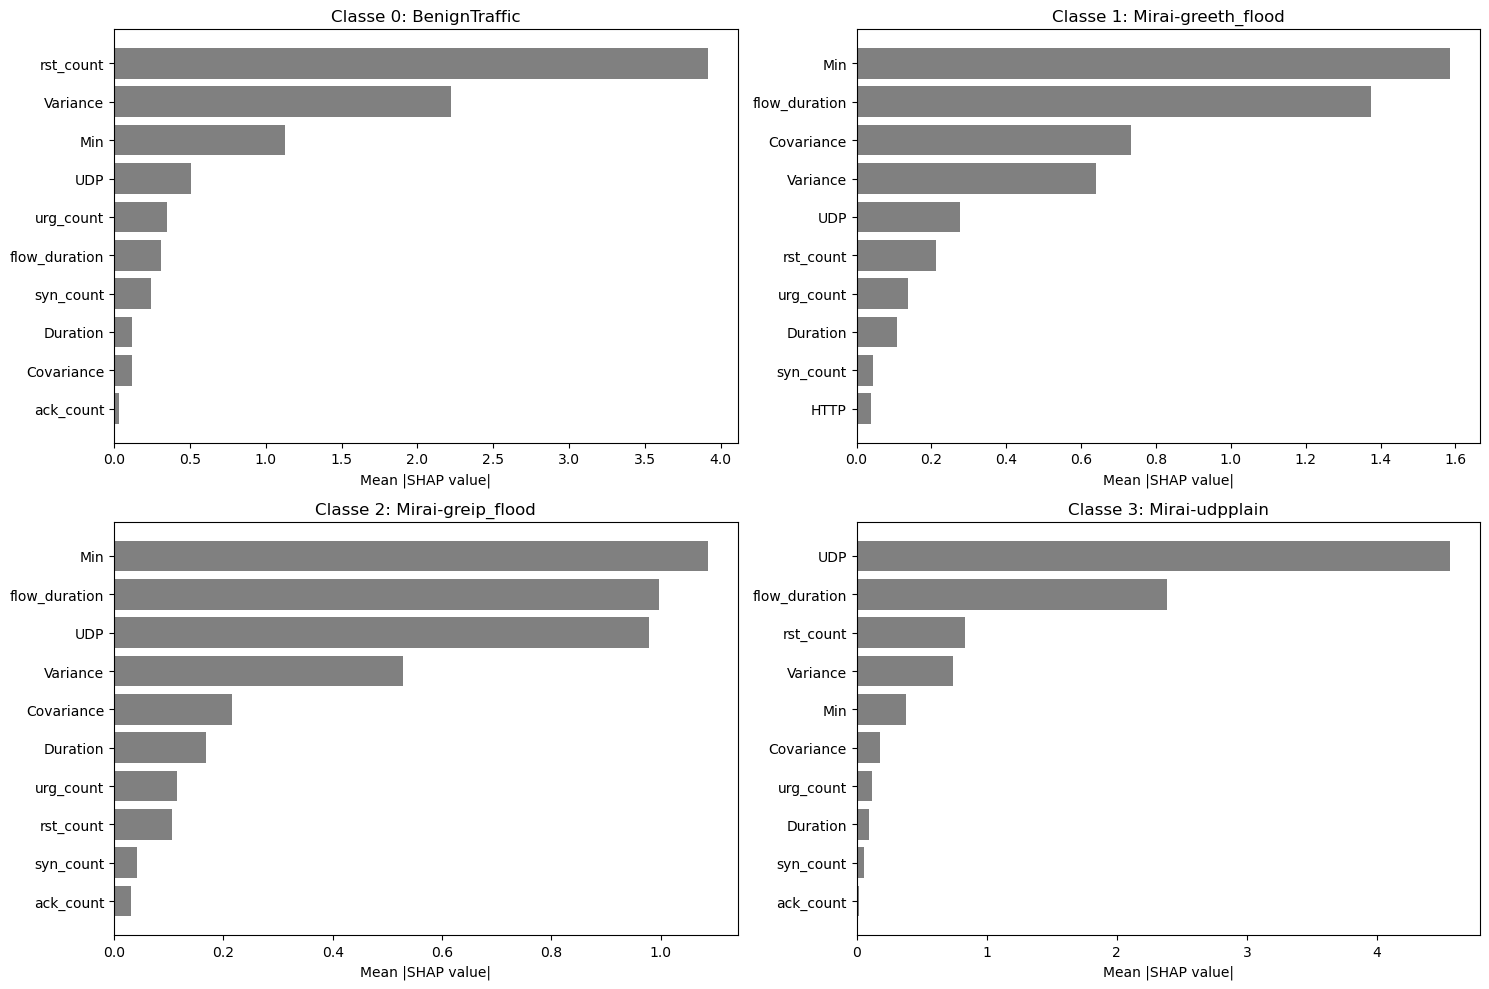

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Mapeamento manual
class_map = {
    0: "BenignTraffic",
    1: "Mirai-greeth_flood",
    2: "Mirai-greip_flood",
    3: "Mirai-udpplain"
}

# Amostra SHAP
amostras = 500
X_sample_lgbm = pd.DataFrame(X_test_lgbm[:amostras], columns=X_lgbm.columns)

# Criar explicador e calcular
explainer = shap.Explainer(model_lgbm_final)
shap_values = explainer(X_sample_lgbm)

# Desnormalizar

X_sample_desnorm = X_sample_lgbm.copy()
X_sample_desnorm = X_sample_desnorm * scaler.scale_ + scaler.mean_

# Preparar subplots 2x2
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

# Para cada classe
for classe_alvo in range(4):
    classe_nome = class_map[classe_alvo]

    mean_abs_shap = np.abs(shap_values.values[:, :, classe_alvo]).mean(axis=0)
    feature_names = X_sample_lgbm.columns

    order = np.argsort(mean_abs_shap)[::-1]
    top_n = 10
    mean_abs_shap_sorted = mean_abs_shap[order][:top_n]
    feature_names_sorted = feature_names[order][:top_n]

    axs[classe_alvo].barh(feature_names_sorted, mean_abs_shap_sorted, color='gray')
    axs[classe_alvo].invert_yaxis()
    axs[classe_alvo].set_title(f"Classe {classe_alvo}: {classe_nome}")
    axs[classe_alvo].set_xlabel("Mean |SHAP value|")

    # Mostrar valores reais médios
    print(f"\n=== {classe_nome} ===")
    for f, shap_w in zip(feature_names_sorted, mean_abs_shap_sorted):
        real_mean = X_sample_desnorm[f].mean()
        print(f"{f:20} | Real Mean: {real_mean:10.3f} | Mean |SHAP|: {shap_w:.5f}")

plt.tight_layout()

#  Salvar PNG + PDF
plt.savefig("shap_comparativo_cinza.png", dpi=300)
plt.savefig("shap_comparativo_cinza.pdf")
print("Gráficos salvos em PDF e PNG.")

plt.show()


Matriz de confusão LGBM:

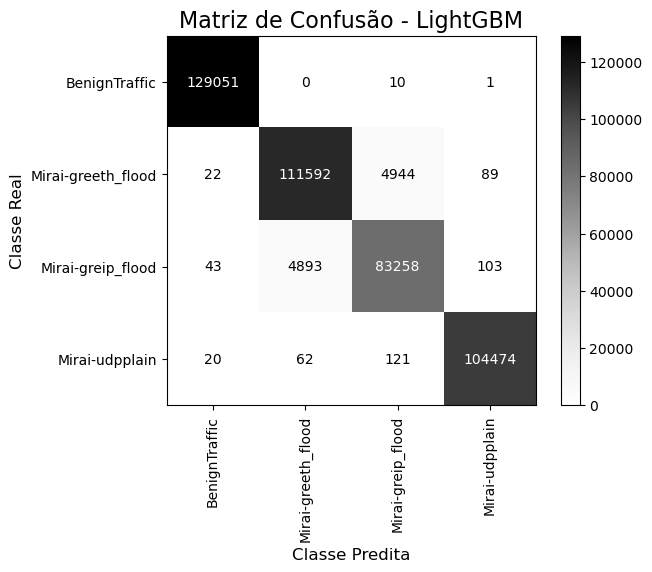

In [21]:
# Gerar a matriz de confusão para o modelo LightGBM
conf_matrix_lgb = confusion_matrix(y_test_lgbm, y_test_pred_lgbm)

# Recuperar o LabelEncoder do dicionário label_encoders
# Supondo que o nome da coluna original do label é 'label'
le_label = label_encoders['label']

# Recuperar os nomes originais das classes para o LightGBM
class_names_lgb = [str(label) for label in le_label.inverse_transform(range(len(le_label.classes_)))]

# Exibir a matriz de confusão para o modelo LightGBM
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lgb, display_labels=class_names_lgb)
disp.plot(cmap="Greys", xticks_rotation='vertical', values_format=".0f")

# ==========================================
# MUDANÇA DOS RÓTULOS DOS EIXOS PARA PORTUGUÊS
# ==========================================
plt.xlabel("Classe Predita", fontsize=12)
plt.ylabel("Classe Real", fontsize=12)

# Adicionar título
plt.title("Matriz de Confusão - LightGBM", fontsize=16)

# Salvar o gráfico
plt.savefig("matriz_confusao_lgbm.pdf", bbox_inches='tight')
plt.show()

BASELINE

In [32]:
# --- Script Completo para Treino e Avaliação do Decision Tree (Baseline) ---

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier  # 1. Importar o DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef
)

# --- CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
# Assumindo que a variável 'novo_dataset' (um DataFrame pandas) já foi carregada
# Exemplo:
# novo_dataset = pd.read_csv('seu_dataset_tratado.csv')

# Separar as features e o label
X_dt = novo_dataset.drop(columns=['label'])
y_dt = novo_dataset['label']

# Dividir os dados em treino e teste (usando a mesma divisão dos outros modelos)
X_train_dt, X_temp_dt, y_train_dt, y_temp_dt = train_test_split(X_dt, y_dt, test_size=0.3, stratify=y_dt, random_state=42)
X_val_dt, X_test_dt, y_val_dt, y_test_dt = train_test_split(X_temp_dt, y_temp_dt, test_size=0.5, stratify=y_temp_dt, random_state=42)

# Normalizar os dados com StandardScaler
scaler_dt = StandardScaler()
X_train_scaled_dt = scaler_dt.fit_transform(X_train_dt)
X_test_scaled_dt = scaler_dt.transform(X_test_dt)

# --- TREINAMENTO DO MODELO ---
# 2. Criar o modelo Decision Tree com parâmetros padrão
model_dt = DecisionTreeClassifier(random_state=42)

print("Iniciando o treinamento do modelo Decision Tree (Baseline)...")
start_train_time = time.time()
model_dt.fit(X_train_scaled_dt, y_train_dt)
training_time_dt = time.time() - start_train_time
print(f"Treinamento concluído em {training_time_dt:.4f} segundos.")


# --- INFERÊNCIA NO CONJUNTO DE TESTE ---
print("\nIniciando a inferência no conjunto de teste...")
start_inference_time = time.time()
y_test_pred_dt = model_dt.predict(X_test_scaled_dt)
inference_time_dt = time.time() - start_inference_time
print(f"Inferência concluída em {inference_time_dt:.4f} segundos.")


# --- CÁLCULO DE MÉTRICAS COMPLETAS ---
test_accuracy_dt = accuracy_score(y_test_dt, y_test_pred_dt)
test_balanced_accuracy_dt = balanced_accuracy_score(y_test_dt, y_test_pred_dt)
test_f1_dt = f1_score(y_test_dt, y_test_pred_dt, average='macro')
test_kappa_dt = cohen_kappa_score(y_test_dt, y_test_pred_dt)
test_mcc_dt = matthews_corrcoef(y_test_dt, y_test_pred_dt)


# --- EXIBIÇÃO DOS RESULTADOS ---
print("\n" + "="*40)
print("  Resultados Finais - Decision Tree (Baseline)")
print("="*40)

print(f"\n--- Tempos ---")
print(f"Tempo de Treinamento: {training_time_dt:.4f} segundos")
print(f"Tempo de Inferência: {inference_time_dt:.4f} segundos")

print(f"\n--- Métricas de Desempenho (Conjunto de Teste) ---")
print(f"Acurácia: {test_accuracy_dt:.4f}")
print(f"Acurácia Balanceada: {test_balanced_accuracy_dt:.4f}")
print(f"F1-Score (Macro): {test_f1_dt:.4f}")
print(f"Kappa de Cohen: {test_kappa_dt:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {test_mcc_dt:.4f}")

print("\n--- Relatório de Classificação por Classe ---")
print(classification_report(y_test_dt, y_test_pred_dt))
print("="*40)

Iniciando o treinamento do modelo Decision Tree (Baseline)...
Treinamento concluído em 26.6024 segundos.

Iniciando a inferência no conjunto de teste...
Inferência concluída em 0.0632 segundos.

  Resultados Finais - Decision Tree (Baseline)

--- Tempos ---
Tempo de Treinamento: 26.6024 segundos
Tempo de Inferência: 0.0632 segundos

--- Métricas de Desempenho (Conjunto de Teste) ---
Acurácia: 0.9691
Acurácia Balanceada: 0.9663
F1-Score (Macro): 0.9663
Kappa de Cohen: 0.9585
Matthews Correlation Coefficient (MCC): 0.9585

--- Relatório de Classificação por Classe ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    129062
           1       0.94      0.94      0.94    116647
           2       0.93      0.93      0.93     88297
           3       1.00      1.00      1.00    104677

    accuracy                           0.97    438683
   macro avg       0.97      0.97      0.97    438683
weighted avg       0.97      0.97      0.97    

MODELO TREINADO E BASE GERADA PELO GERADOR SINTÉTICO:

Validador Multiclasse de Tráfego 5G (Inferência Fog/NWDAF)
Este script processa ficheiros com múltiplos tipos de ataque, classifica-os,
extrai explicações SHAP globais, gera a Matriz de Confusão Vetorial e 
calcula a Fidelidade Física (Wasserstein W1 Absoluto, Medianas e IQR) iterando 
por cada classe de ataque presente no laboratório face à base original.


In [16]:
# -*- coding: utf-8 -*-
"""

"""
import os
import pandas as pd
import numpy as np
import joblib
from scipy.stats import wasserstein_distance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar warnings de features sem nome válido
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# CONFIGURAÇÕES DO TESTBED
# =============================================================================
CAMINHO_MODELO = 'lightgbm.pkl'
CAMINHO_SCALER = 'scaler_lgbm.pkl'

# O SEU NOVO TRÁFEGO GERADO (com múltiplos ataques e a coluna 'label')
CAMINHO_CSV_TESTE = '../synthgen/synth_5g_unificado.csv'

# Caminho para o CSV com o tráfego real (CICIoT) para comparar Média e W1
CAMINHO_CSV_REAL = '../CiCIot2023/CIC_IoT_Dataset_Unificado_resumido.csv'

NOME_COLUNA_ALVO = 'label'

# Mapeamento essencial para converter as strings de ataque em números para a IA
MAPA_CLASSES = {
    'BenignTraffic': 0,
    'Mirai-greeth_flood': 1,
    'Mirai-greip_flood': 2,
    'Mirai-udpplain': 3
    # Adicione outras variantes aqui se o seu gerador as produzir
}
# Criar o mapa inverso para exibição legível
MAPA_INVERSO = {v: k for k, v in MAPA_CLASSES.items()}

FEATURE_ALIASES = {
    'Duration': 'time_to_live',
    'flow_duration': 'Flow Duration',
    'HTTP': 'http',
    'UDP': 'udp',
    'Covariance': 'covariance',
    'Variance': 'variance',
}

APLICAR_MASCARA_HYPERVISOR = False

# =============================================================================
# FUNÇÕES AUXILIARES
# =============================================================================
def _resolver_coluna(nome_modelo, orig, lower):
    if nome_modelo in orig:
        return orig[nome_modelo], nome_modelo, True
    key = nome_modelo.lower()
    if key in lower:
        return lower[key], key, True
    spaced = key.replace('_', ' ')
    if spaced in lower:
        return lower[spaced], spaced, True
    alias = FEATURE_ALIASES.get(nome_modelo)
    if alias:
        for candidate in (alias, alias.replace('_', ' '), alias.replace(' ', '_')):
            if candidate in orig:
                return orig[candidate], candidate, True
            ck = candidate.lower()
            if ck in lower:
                return lower[ck], ck, True
    return None, None, False

def calcular_iqr(vals):
    """Calcula o Intervalo Interquartil (IQR) para análise robusta."""
    if len(vals) == 0:
        return 0.0
    q75, q25 = np.percentile(vals, [75, 25])
    return q75 - q25

def gerar_matriz_confusao(y_true, y_pred, target_names):
    """Gera uma Matriz de Confusão em formato PDF padrão IEEE/Qualis."""
    print("\n[*] A gerar Matriz de Confusão para o Testbed...")
    cm = confusion_matrix(y_true, y_pred)
    
    # Evita divisão por zero caso alguma classe não tenha amostras
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = np.true_divide(cm, cm.sum(axis=1)[:, np.newaxis])
        cm_norm[~np.isfinite(cm_norm)] = 0
    
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="white", font_scale=1.2)
    
    annot_data = []
    for i in range(cm.shape[0]):
        row_annot = []
        for j in range(cm.shape[1]):
            row_annot.append(f"{cm[i, j]}\n({cm_norm[i, j]:.1%})")
        annot_data.append(row_annot)
    
    ax = sns.heatmap(cm_norm, annot=annot_data, fmt='', cmap='Greys', 
                     cbar=True, square=True, vmin=0, vmax=1,
                     xticklabels=target_names, yticklabels=target_names,
                     annot_kws={"size": 11, "weight": "bold"})
    
    plt.title('Matriz de Confusão: Classificação Operacional no Testbed 5G', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Classe Verdadeira (Injetada)', fontsize=12, fontweight='bold')
    plt.xlabel('Classe Predita (Modelo na Névoa)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig('matriz_confusao_testbed.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    print("[+] Gráfico salvo: matriz_confusao_testbed.pdf")

def analisar_shap_multiclasse(modelo, X):
    print("\n[*] A calcular contribuições SHAP globais (Isto pode demorar um pouco)...")
    
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        print("[*] A gerar gráfico SHAP Summary Multiclasse...")
        shap.summary_plot(shap_values, X, show=False, class_names=[MAPA_INVERSO.get(i, f"Class {i}") for i in range(len(shap_values))])
        plt.tight_layout()
        plt.savefig('shap_summary_multiclasse.png')
        print("[+] Gráfico SHAP salvo: shap_summary_multiclasse.png")
        
        for idx, shap_array in enumerate(shap_values):
            nome_classe = MAPA_INVERSO.get(idx, f"Classe {idx}")
            print(f"\n--- Top 3 Features Decisivas para: {nome_classe} ---")
            mean_abs = np.abs(shap_array).mean(axis=0).flatten()
            if len(mean_abs) != len(X.columns):
                mean_abs = mean_abs[:len(X.columns)]
            
            df_shap = pd.DataFrame({'Feature': X.columns, 'Impacto_Absoluto': mean_abs})
            df_shap.sort_values(by='Impacto_Absoluto', ascending=False, inplace=True)
            print(df_shap.head(3).to_string(index=False, float_format=lambda x: f"{x:.5f}"))
            
    else:
        print("\n--- Análise SHAP (Modelo de Matriz Única) ---")
        shap.summary_plot(shap_values, X, show=False)
        plt.tight_layout()
        plt.savefig('shap_summary_global.png')
        print("[+] Gráfico salvo: shap_summary_global.png")

# =============================================================================
# FUNÇÃO PRINCIPAL
# =============================================================================
def validar_modelo():
    print('=' * 60)
    print('    INFERÊNCIA MULTICLASSE DE SEGURANÇA 5G (NÉVOA)    ')
    print('=' * 60)

    # 1. Carregar Modelo
    try:
        modelo = joblib.load(CAMINHO_MODELO)
        scaler = joblib.load(CAMINHO_SCALER)
    except FileNotFoundError as e:
        print(f'❌ Erro ao carregar ficheiro: {e}')
        return

    # 2. Carregar Tráfego Testbed
    try:
        df = pd.read_csv(CAMINHO_CSV_TESTE)
    except FileNotFoundError:
        print(f"❌ Erro: Não foi possível encontrar '{CAMINHO_CSV_TESTE}'.")
        return

    if NOME_COLUNA_ALVO not in df.columns:
        print(f"❌ Erro crítico: A coluna '{NOME_COLUNA_ALVO}' não foi encontrada no ficheiro CSV.")
        return

    # 3. Mapeamento de Classes
    y_true_texto = df[NOME_COLUNA_ALVO].astype(str).str.strip()
    y_true_numerico = y_true_texto.map(MAPA_CLASSES)
    
    classes_nao_mapeadas = y_true_texto[y_true_numerico.isna()].unique()
    if len(classes_nao_mapeadas) > 0:
        print(f"⚠️ Aviso: Encontradas variantes não mapeadas ({classes_nao_mapeadas}). Adicione-as ao MAPA_CLASSES.")
        df = df[y_true_numerico.notna()]
        y_true_texto = df[NOME_COLUNA_ALVO].astype(str).str.strip()
        y_true_numerico = y_true_texto.map(MAPA_CLASSES)

    y_true = y_true_numerico.astype(int).values
    X = df.drop(columns=[NOME_COLUNA_ALVO])

    print(f"[*] Encontrados {len(df)} fluxos válidos.")
    print("[*] Variantes presentes neste ficheiro:", list(y_true_texto.unique()))

    # 4. Alinhamento de Features
    dados_orig = {col.strip(): X[col].values for col in X.columns}
    dados_lower = {col.strip().lower(): X[col].values for col in X.columns}

    novo_X = pd.DataFrame(index=X.index)
    
    if hasattr(modelo, 'feature_name_'):
        features_esperadas = modelo.feature_name_
    elif hasattr(modelo, 'feature_names_in_'):
        features_esperadas = modelo.feature_names_in_
    elif hasattr(scaler, 'feature_names_in_'):
        features_esperadas = scaler.feature_names_in_
    else:
        features_esperadas = X.columns 
        
    for expected in features_esperadas:
        expected_str = str(expected).strip()
        vals, src, ok = _resolver_coluna(expected_str, dados_orig, dados_lower)
        if ok:
            novo_X[expected_str] = vals
        else:
            novo_X[expected_str] = 0.0

    X_raw = novo_X.copy()
    X_scaled = novo_X.copy()
    
    # 5. Normalização e Inferência
    colunas_numericas = X_scaled.select_dtypes(include=np.number).columns
    X_scaled[colunas_numericas] = scaler.transform(X_scaled[colunas_numericas])

    print('\n[*] A executar Classificação no Tráfego 5G...')
    y_pred = modelo.predict(X_scaled)

    # 6. SHAP
    #analisar_shap_multiclasse(modelo, X_scaled)

    # 7. Relatório Global
    print('\n=======================================================')
    print('        MÉTRICAS GLOBAIS - TESTBED 5G EMULADO          ')
    print('=======================================================')
    print(f'Acurácia (Accuracy) : {accuracy_score(y_true, y_pred):.4f}')
    print('\nRelatório de Classificação Detalhado:')
    target_names = [MAPA_INVERSO[i] for i in sorted(np.unique(np.concatenate((y_true, y_pred))))]
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    # 8. Matriz de Confusão em PDF
    gerar_matriz_confusao(y_true, y_pred, target_names)

    # =========================================================================
    # AVALIAÇÃO DE FIDELIDADE FÍSICA (W1 Absoluto) POR CLASSE
    # =========================================================================
    print('\n' + '=' * 60)
    print(' 📏 ANÁLISE DE FIDELIDADE (W1 ABSOLUTO) POR VARIANTE')
    print('=' * 60)

    try:
        df_real_full = pd.read_csv(CAMINHO_CSV_REAL)
        col_label_real = None
        for col in df_real_full.columns:
            if col.strip().lower() in ['label', 'class', 'target']:
                col_label_real = col
                break
                
        if col_label_real is None:
            raise ValueError("Coluna 'label' não encontrada no arquivo real CICIoT.")
            
        df_real_full[col_label_real] = df_real_full[col_label_real].astype(str).str.strip()

        # Usando as variáveis principais que você costuma validar
        diag_cols = [c for c in ['flow_duration','rst_count','Duration', 'Covariance', 'Variance', 'Min', 'UDP'] if c in novo_X.columns]
        
        classes_no_teste = y_true_texto.unique()
        
        for classe_alvo in classes_no_teste:
            print(f"\n--- 🔎 Analisando Física para: {classe_alvo} ---")
            
            idx_teste = (y_true_texto == classe_alvo)
            X_raw_classe = X_raw[idx_teste]
            df_real_filtrado = df_real_full[df_real_full[col_label_real] == classe_alvo]
            
            if df_real_filtrado.empty:
                print(f"⚠️ Variante '{classe_alvo}' não encontrada na base original CICIoT. Saltando...")
                continue
                
            dados_real_lower = {col.strip().lower(): df_real_filtrado[col].values for col in df_real_filtrado.columns}
            
            w1_records = []
            for col in diag_cols:
                vals_synth = X_raw_classe[col].dropna().values
                vals_real = None
                
                if col in df_real_filtrado.columns:
                    vals_real = df_real_filtrado[col].dropna().values
                elif col.lower() in dados_real_lower:
                    vals_real = dados_real_lower[col.lower()]
                elif FEATURE_ALIASES.get(col, "").lower() in dados_real_lower:
                    vals_real = dados_real_lower[FEATURE_ALIASES[col].lower()]
                    
                if vals_real is not None and len(vals_real) > 0 and len(vals_synth) > 0:
                    w1_dist = wasserstein_distance(vals_real, vals_synth)

                    w1_records.append({
                        'Feature': col,
                        'Mediana 5G': np.median(vals_synth),
                        'Mediana Legada': np.median(vals_real),
                        'IQR 5G': calcular_iqr(vals_synth),
                        'IQR Legada': calcular_iqr(vals_real),
                        'W1 Absoluto': w1_dist
                    })
            
            if w1_records:
                df_w1 = pd.DataFrame(w1_records)
                df_w1 = df_w1[['Feature', 'Mediana Legada', 'Mediana 5G', 'IQR Legada', 'IQR 5G', 'W1 Absoluto']]
                df_w1.sort_values(by='W1 Absoluto', ascending=False, inplace=True)
                print(df_w1.round(4).to_string(index=False))
            else:
                print("Nenhuma feature em comum para calcular a distância.")
                
    except Exception as e:
        print(f"❌ Erro ao processar arquivo Real CICIoT para W1: {e}")

if __name__ == '__main__':
    validar_modelo()

    INFERÊNCIA MULTICLASSE DE SEGURANÇA 5G (NÉVOA)    
[*] Encontrados 8120 fluxos válidos.
[*] Variantes presentes neste ficheiro: ['BenignTraffic', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain']

[*] A executar Classificação no Tráfego 5G...

        MÉTRICAS GLOBAIS - TESTBED 5G EMULADO          
Acurácia (Accuracy) : 0.9824

Relatório de Classificação Detalhado:
                    precision    recall  f1-score   support

     BenignTraffic       0.99      0.96      0.97      1500
Mirai-greeth_flood       0.97      0.99      0.98      1500
 Mirai-greip_flood       0.96      0.98      0.97      1500
    Mirai-udpplain       1.00      0.99      0.99      3620

          accuracy                           0.98      8120
         macro avg       0.98      0.98      0.98      8120
      weighted avg       0.98      0.98      0.98      8120


[*] A gerar Matriz de Confusão para o Testbed...
[+] Gráfico salvo: matriz_confusao_testbed.pdf

 📏 ANÁLISE DE FIDELIDADE (W1 ABSOLUT

A carregar os datasets reais e sintéticos...
Gerando as visualizações comparativas...

Gerando gráficos de validação XAI para: BenignTraffic...


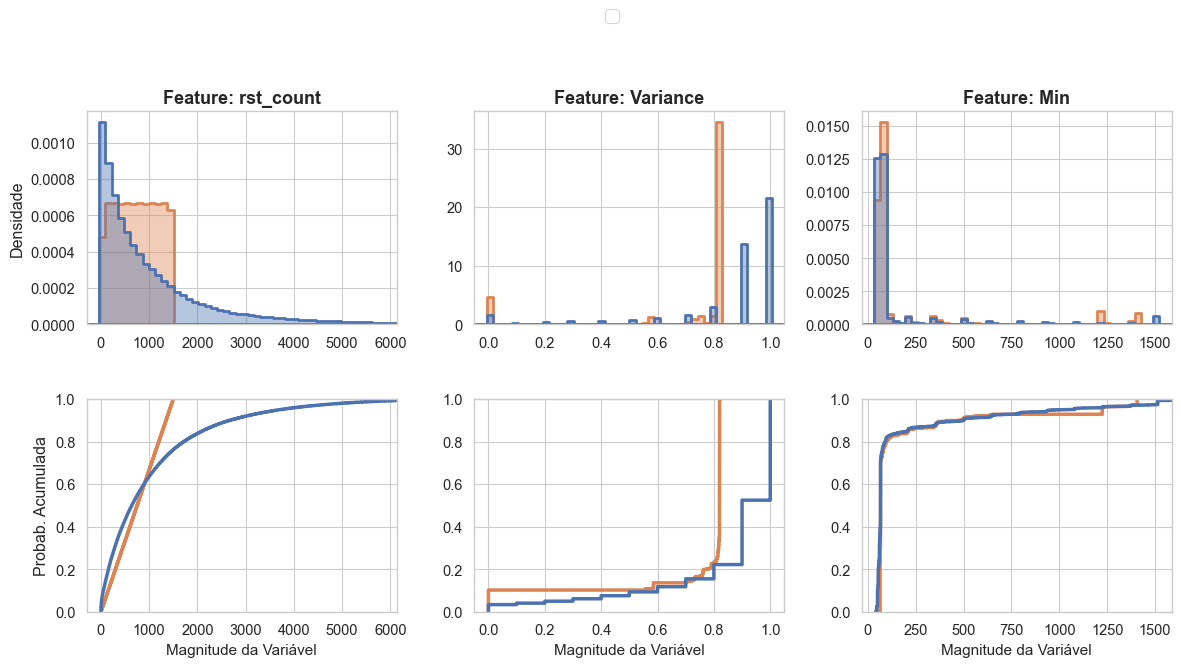


Gerando gráficos de validação XAI para: Mirai-greeth_flood...


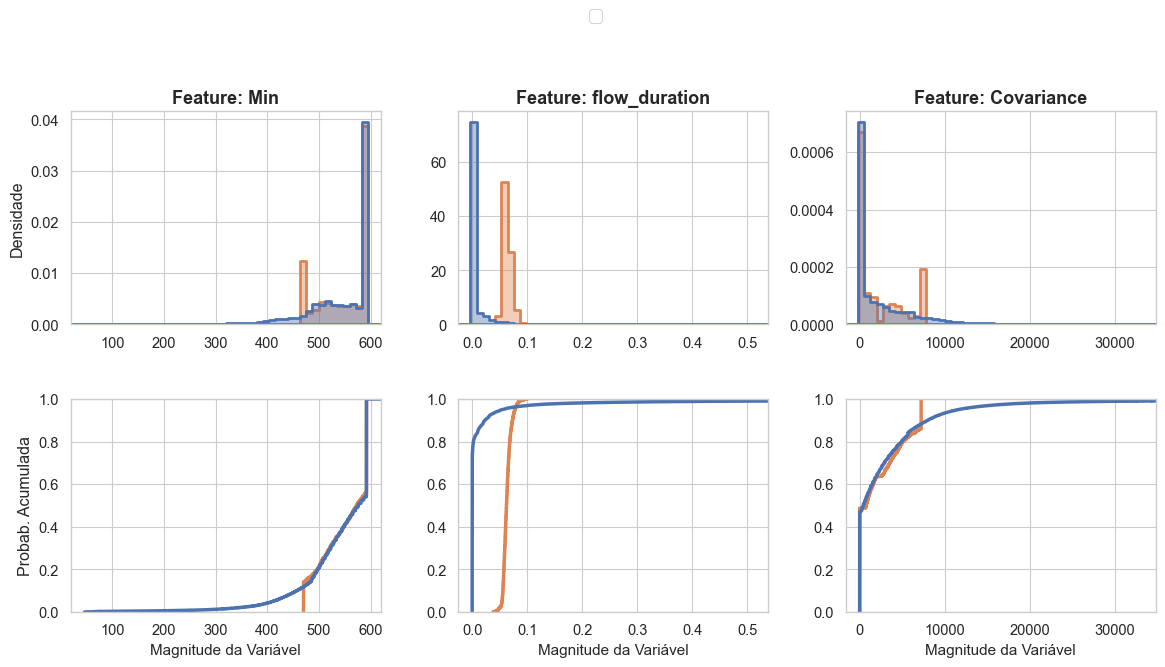


Gerando gráficos de validação XAI para: Mirai-greip_flood...


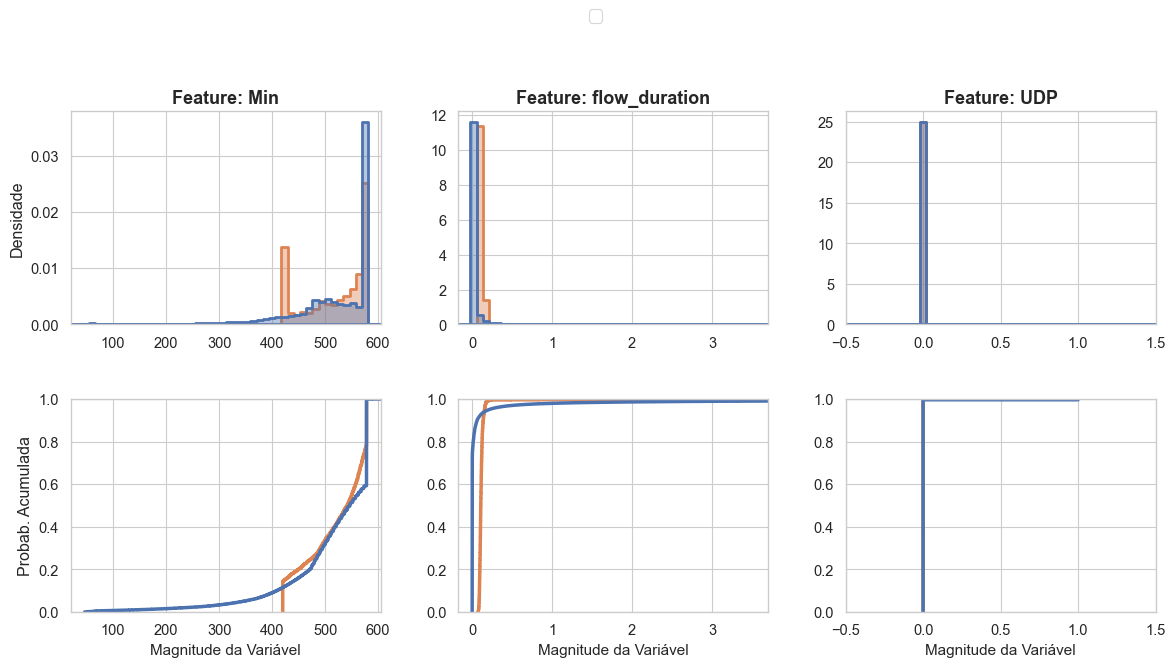


Gerando gráficos de validação XAI para: Mirai-udpplain...


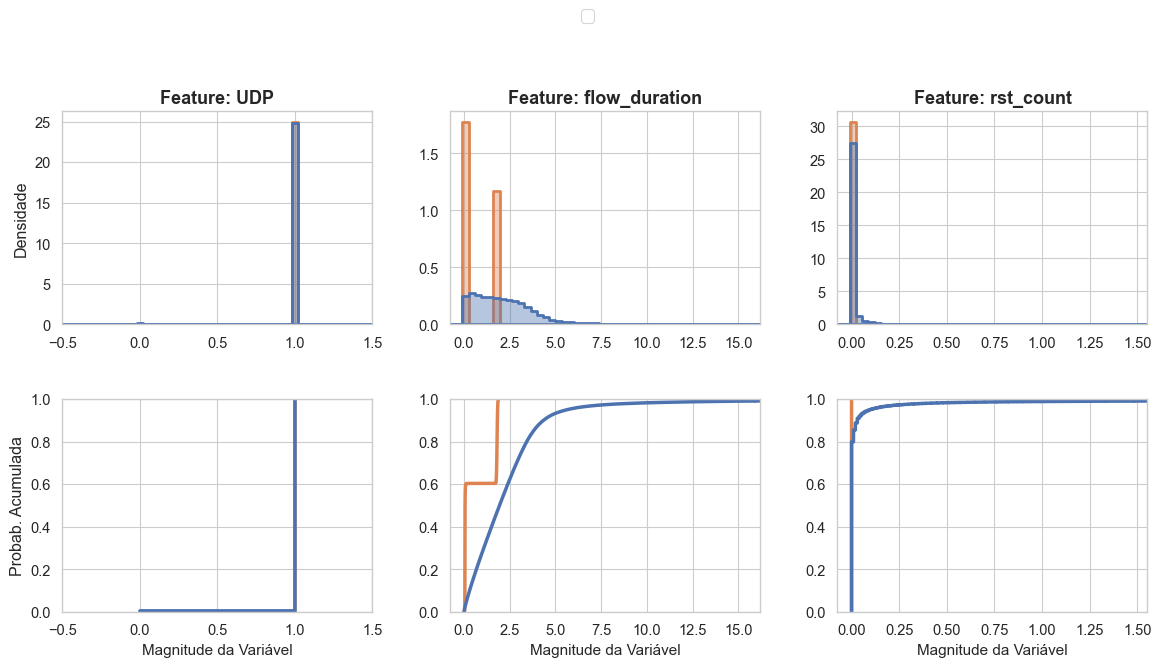

In [19]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# SCRIPT DE VALIDAÇÃO VISUAL (VERSÃO JUPYTER NOTEBOOK - DADOS REAIS)
# Exibe Histograma e ECDF renderizados diretamente na célula.
# =============================================================================

SHAP_TOP_FEATURES = {
    'BenignTraffic': ['rst_count', 'Variance', 'Min'],
    'Mirai-greeth_flood': ['Min', 'flow_duration', 'Covariance'],
    'Mirai-greip_flood': ['Min', 'flow_duration', 'UDP'],
    'Mirai-udpplain': ['UDP', 'flow_duration', 'rst_count']
}

def normalizar_coluna(df, col_desejada):
    if col_desejada in df.columns: return col_desejada
    col_alt = col_desejada.replace('_', ' ')
    if col_alt in df.columns: return col_alt
    col_alt2 = col_desejada.replace(' ', '_')
    if col_alt2 in df.columns: return col_alt2
    return None

def gerar_graficos_limpos(variante, df_real, df_synth, col_label_real, col_label_synth):
    print(f"\nGerando gráficos de validação XAI para: {variante}...")
    
    df_real_filtrado = df_real[df_real[col_label_real] == variante]
    df_synth_filtrado = df_synth[df_synth[col_label_synth] == variante] if col_label_synth else df_synth
    
    features = SHAP_TOP_FEATURES[variante]
    
    # Configuração de estilo (Estética científica e limpa)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    cores = ['#4C72B0', '#DD8452'] # Azul (Real) e Laranja (5G Sintético)
    
    # Figura retangular ajustada para Notebook
    fig = plt.figure(figsize=(14, 6.5))
    
    # Grid: 2 linhas (Hist, ECDF) e 3 colunas (Features)
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.35, wspace=0.25)
    
    for i, feat in enumerate(features):
        ax_hist = fig.add_subplot(gs[0, i])
        ax_ecdf = fig.add_subplot(gs[1, i])
        
        col_r = normalizar_coluna(df_real_filtrado, feat)
        col_s = normalizar_coluna(df_synth_filtrado, feat)
        
        if col_r and col_s:
            v_real = df_real_filtrado[col_r].dropna().values
            v_synth = df_synth_filtrado[col_s].dropna().values
            
            df_plot = pd.DataFrame({
                'Valor': np.concatenate([v_real, v_synth]),
                'Ambiente': ['Real (CICIoT2023)'] * len(v_real) + ['Sintético (Emulado 5G)'] * len(v_synth)
            })
            
            # Limites visuais (Corte no percentil 99 para foco na massa de dados)
            p01, p99 = np.percentile(df_plot['Valor'], 0), np.percentile(df_plot['Valor'], 99)
            if len(np.unique(df_plot['Valor'])) <= 2 or p99 == p01:
                margem = 0.5
                xlims = (df_plot['Valor'].min() - margem, df_plot['Valor'].max() + margem)
            else:
                margem = (p99 - p01) * 0.05
                xlims = (p01 - margem, p99 + margem)

            # 1. HISTOGRAMA (Densidade)
            sns.histplot(data=df_plot, x='Valor', hue='Ambiente', ax=ax_hist, 
                         palette=cores, element="step", fill=True, stat="density", 
                         common_norm=False, alpha=0.4, linewidth=2,
                         bins=50, binrange=xlims)
            
            ax_hist.set_title(f"Feature: {feat}", fontweight='bold', fontsize=13)
            ax_hist.set_xlim(xlims)
            ax_hist.set_xlabel("")
            ax_hist.set_ylabel("Densidade" if i == 0 else "")
            if ax_hist.get_legend(): ax_hist.get_legend().remove()

            # 2. ECDF (Distribuição Acumulada)
            sns.ecdfplot(data=df_plot, x='Valor', hue='Ambiente', ax=ax_ecdf, 
                         palette=cores, linewidth=2.5)
            ax_ecdf.set_xlim(xlims)
            ax_ecdf.set_xlabel("Magnitude da Variável", fontsize=11)
            ax_ecdf.set_ylabel("Probab. Acumulada" if i == 0 else "")
            if ax_ecdf.get_legend(): ax_ecdf.get_legend().remove()
        else:
            ax_hist.text(0.5, 0.5, "Ausente", ha='center', va='center')
            ax_ecdf.text(0.5, 0.5, "Ausente", ha='center', va='center')

    # Legenda Global (Top Center)
    handles, labels = ax_hist.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=12, frameon=True)
    
  
    plt.show()

# =============================================================================
# BLOCO DE EXECUÇÃO PRINCIPAL
# =============================================================================

caminho_csv_real = '../CiCIot2023/CIC_IoT_Dataset_Unificado_resumido.csv'
caminho_csv_synth = '../synthgen/synth_5g_unificado.csv'

print("A carregar os datasets reais e sintéticos...")
try:
    df_real = pd.read_csv(caminho_csv_real)
    df_synth = pd.read_csv(caminho_csv_synth)
    
    col_label_real = normalizar_coluna(df_real, 'label') or normalizar_coluna(df_real, 'Label')
    col_label_synth = normalizar_coluna(df_synth, 'label') or normalizar_coluna(df_synth, 'Label')

    print("Gerando as visualizações comparativas...")
    # 2. Gera os gráficos apenas para as variantes que existem no dataset
    for variante in SHAP_TOP_FEATURES.keys():
        if variante in df_real[col_label_real].unique():
            gerar_graficos_limpos(variante, df_real, df_synth, col_label_real, col_label_synth)
            
except FileNotFoundError as e:
    print(f"\n[ERRO] Não foi possível encontrar o arquivo: {e}")
    print("Verifique se os caminhos 'caminho_csv_real' e 'caminho_csv_synth' estão corretos.")